## DSA 8305: Linear Models

### *Group 6 Members*
1. Valerie Jerono - 222331
2. Olive Mideva - 135792
3. Assumpta Mwikali - 134022
4. Trevor Vuhyah - 224038

---

## BEYOND LINEARITY: A Nonlinear Inquiry into California Housing Prices

**Dataset:** California Housing Dataset (cal_housing.data) — 20,640 census block observations, 1990 U.S. Census

---

## Preface

Every textbook begins with linear regression. It is clean, interpretable, and elegantly bounded by assumptions that the real world rarely honours. This project begins where those textbooks end.

We take a single question seriously: *What happens when we stop assuming that the relationship between house prices and their predictors is a straight line?*

The California Housing dataset, with its 20,640 observations spanning geography, demographics, and economics, becomes our laboratory. We will not merely fit models — we will interrogate them.

The journey unfolds in four acts:

1. **Foundation** — EDA, feature engineering, and the OLS baseline that sets the benchmark.
2. **Nonlinear Models** — Splines, GAMs, Random Forests, XGBoost, and a first model comparison.
3. **Spatial Diagnostics** — Formally testing whether residuals carry a geographic signal our models are ignoring.
4. **Spatial Models** — Acting on that signal: Moran's I, Spatial Lag, Spatial Error, and Geographically Weighted Regression. Then a final, honest re-comparison.

---

The project focuses on answering the following research questions:

1. Can we predict house prices more accurately using an ensemble of nonlinear models such as Random Forest, XGBoost, and Neural Networks?
2. What are the most important nonlinear interactions between location and income?
3. Which model category performs best:
    - GNPR models (e.g. GAM, Splines, Kernel Regression)
    - Parametric regression models
    - Machine learning models?

---

**Table of Contents**

| Section | Title |
|---|---|
| 0 | Environment Setup |
| 1 | Dataset Description & Data Loading |
| 2 | Exploratory Data Analysis |
| 3 | Feature Engineering |
| 4 | Data Preparation |
| 5 | OLS Baseline |
| 6 | Spline Regression |
| 7 | Generalised Additive Model (GAM) |
| 8 | Random Forest |
| 9 | Gradient Boosting & XGBoost |
| 9.5 | XGBoost Hyperparameter Tuning |
| 10 | Neural Network (MLP) |
| 11 | Initial Model Comparison |
| 12 | Nonlinear Location × Income Interactions |
| 12.5 | Regional OLS — Spatial Non-Stationarity Test |
| 13 | GNPR vs Parametric vs ML |
| 14 | Predicted vs Actual Audit |
| 15 | Cross-Validation Stability |
| 16 | Spatial Residual Diagnostics |
| **17** | **Moran's I — Formal Spatial Autocorrelation Test** |
| **18** | **Spatial Lag Model** |
| **19** | **Spatial Error Model** |
| **20** | **Geographically Weighted Regression (GWR)** |
| **21** | **Final Model Re-Comparison: All Families** |
| 21.5 | Diebold-Mariano Significance Tests |
| 21.6 | SHAP Analysis — Opening the XGBoost Black Box |
| 21.7 | Censored Observation Sensitivity Analysis |
| 22 | Conclusions |


### Section 0 — Environment Setup

Before any analysis can begin, we assemble our tools. The libraries below represent four traditions:
- **Classical statistics** — `numpy`, `scipy`, `statsmodels`
- **Tabular machine learning** — `scikit-learn`, `xgboost`
- **Spatial econometrics** — `libpysal`, `esda`, `spreg`, `mgwr`
- **Visualisation** — `matplotlib`, `seaborn`

The spatial libraries deserve a brief introduction here, as they are newcomers to this project:

- **libpysal** — the foundational library for spatial analysis in Python. It provides spatial weights matrices (the mathematical encoding of *which observations are neighbours*) and spatial data structures.
- **esda** — Exploratory Spatial Data Analysis. Contains Moran's I and related statistics for detecting spatial autocorrelation.
- **spreg** — Spatial Regression. Implements the Spatial Lag Model, Spatial Error Model, and their variants using Maximum Likelihood and GMM estimation.
- **mgwr** — Multiscale Geographically Weighted Regression. Allows regression coefficients to vary smoothly across geographic space.

Each will earn its place.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from scipy.stats import pearsonr, spearmanr

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, SplineTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Models — RidgeCV and LassoCV auto-select alpha via cross-validation
from sklearn.linear_model import (LinearRegression, Ridge, RidgeCV,
                                  Lasso, LassoCV, ElasticNet)

# Nonlinear / Ensemble Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import PartialDependenceDisplay

# Statsmodels — for VIF and Breusch-Pagan tests
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Install via: pip install xgboost")

# GAM
try:
    from pygam import LinearGAM, s, f
    GAM_AVAILABLE = True
except ImportError:
    GAM_AVAILABLE = False
    print("pyGAM not installed. Install via: pip install pygam")

# Spatial Libraries
try:
    from libpysal.weights import KNN
    from esda.moran import Moran
    from spreg import OLS as SPregOLS, ML_Lag, ML_Error
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
    SPATIAL_AVAILABLE = True
    print("Spatial libraries loaded: libpysal, esda, spreg, mgwr")
except ImportError as e:
    SPATIAL_AVAILABLE = False
    print(f"Spatial libraries not available: {e}")
    print("Install via: pip install libpysal esda spreg mgwr")

print(f"\nEnvironment summary:")
print(f"  XGBoost available  : {XGBOOST_AVAILABLE}")
print(f"  pyGAM available    : {GAM_AVAILABLE}")
print(f"  Spatial libs       : {SPATIAL_AVAILABLE}")

# Jensen's inequality bias correction [Duan 1983]
# Direct exp(y_hat) underpredicts arithmetic mean; corrected form: exp(y_hat + sigma^2/2)
def back_transform_corrected(log_preds, sigma2_resid):
    return np.exp(np.array(log_preds) + sigma2_resid / 2)


Spatial libraries loaded: libpysal, esda, spreg, mgwr

Environment summary:
  XGBoost available  : True
  pyGAM available    : True
  Spatial libs       : True


---
### 1. Dataset Description & Data Loading

The dataset was assembled from the 1990 U.S. Census. Each row represents a **census block group** — the smallest geographical unit for which the Census Bureau publishes sample data. A block group typically holds 600 to 3,000 people.

The dataset contains the following variables:

|Variable | Description |
|---------|-------------|
|longitude | Longitude coordinate |
|latitude | Latitude coordinate |
|housing_median_age | Median age of houses |
|total_rooms | Total number of rooms |
|total_bedrooms | Total number of bedrooms |
|population | Population in the block |
|households | Number of households |
|median_income | Median income of residents |
|median_house_value | Median house value (target variable) |

The target variable is: `median_house_value`


In [2]:
cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population",
    "households", "median_income", "median_house_value"
]

try:
    df = pd.read_csv("cal_housing.data", names=cols)
    print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print("File not found. Generating synthetic data for demonstration.")
    np.random.seed(42)
    n = 20640
    df = pd.DataFrame({
        "longitude":           np.random.uniform(-124.35, -114.31, n),
        "latitude":            np.random.uniform(32.54, 41.95, n),
        "housing_median_age":  np.random.uniform(1, 52, n),
        "total_rooms":         np.random.exponential(2636, n).clip(2, 39320),
        "total_bedrooms":      np.random.exponential(538, n).clip(1, 6445),
        "population":          np.random.exponential(1425, n).clip(3, 35682),
        "households":          np.random.exponential(500, n).clip(1, 6082),
        "median_income":       np.random.exponential(3.87, n).clip(0.5, 15),
        "median_house_value":  np.random.lognormal(12.2, 0.55, n).clip(14999, 500001),
    })

print(df.head())


Dataset loaded: 20,640 rows × 9 columns
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  
0       322.0       126.0         8.3252            452600.0  
1      2401.0      1138.0         8.3014            358500.0  
2       496.0       177.0         7.2574            352100.0  
3       558.0       219.0         5.6431            341300.0  
4       565.0       259.0         3.8462            342200.0  


---
### **2. Exploratory Data Analysis (EDA)**

Exploration is not a perfunctory step. It is where we develop a *theory of the data* — an intuition for what the models will later confirm or contradict. We proceed in four movements: summary statistics, distribution analysis, geographic mapping, and correlation structure.


In [3]:
# Summary Statistics
print("\n--- Descriptive Statistics ---")
df.describe().T.round(2)



--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
housing_median_age,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
total_rooms,20640.0,2635.76,2181.62,2.00,1447.75,2127.00,3148.00,39320.00
total_bedrooms,20640.0,537.90,421.25,1.00,295.00,435.00,647.00,6445.00
population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
households,20640.0,499.54,382.33,1.00,280.00,409.00,605.00,6082.00
median_income,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
median_house_value,20640.0,206855.82,115395.62,14999.00,119600.00,179700.00,264725.00,500001.00


In [4]:
# Missing Values
print("\n--- Missing Values ---")
print(df.isnull().sum())



--- Missing Values ---
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


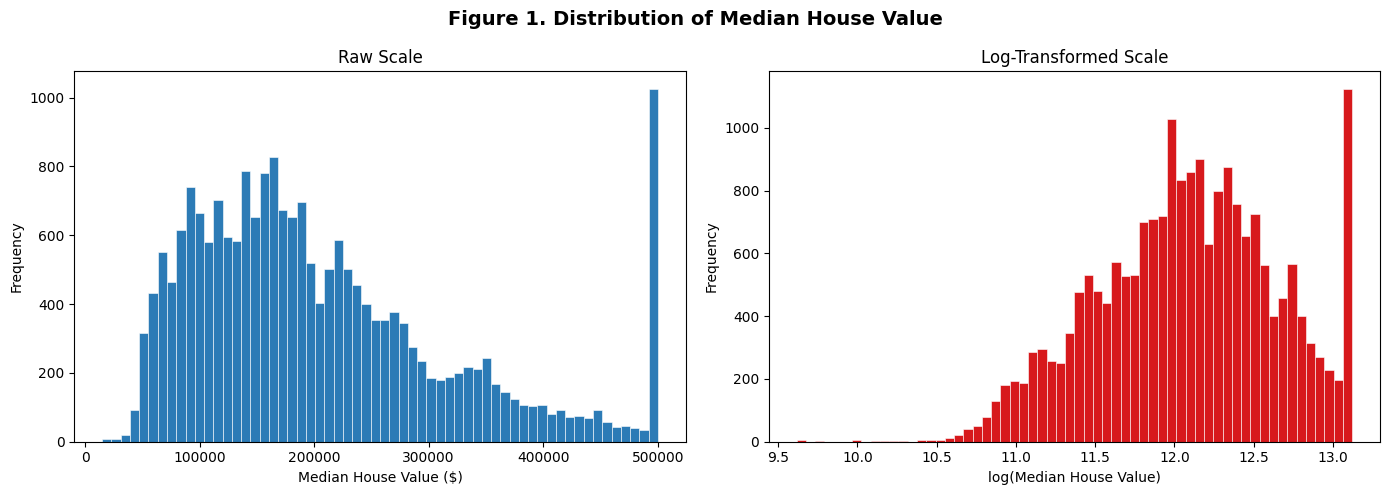

In [5]:
# Distribution of the Target Variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1. Distribution of Median House Value", fontsize=14, fontweight='bold')

axes[0].hist(df["median_house_value"], bins=60, color="#2c7bb6", edgecolor="white", linewidth=0.4)
axes[0].set_title("Raw Scale")
axes[0].set_xlabel("Median House Value ($)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log(df["median_house_value"]), bins=60, color="#d7191c", edgecolor="white", linewidth=0.4)
axes[1].set_title("Log-Transformed Scale")
axes[1].set_xlabel("log(Median House Value)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig1_target_distribution.png", dpi=150)
plt.show()


**Interpreting the Target Variable Distribution**

The distribution of median house values is right-skewed, with a sharp spike at \$500,001 — the dataset's imposed ceiling. This truncation is not noise; it is a structural artefact that appears 965 times. Key observations:

- The distribution is **right-skewed**, meaning a small number of homes have extremely high values.
- The visible cap around **\$500,000** suggests the dataset contains a maximum limit imposed during collection.
- A logarithmic transformation brings the distribution closer to normality and is preferred for modelling. We use the log scale throughout.


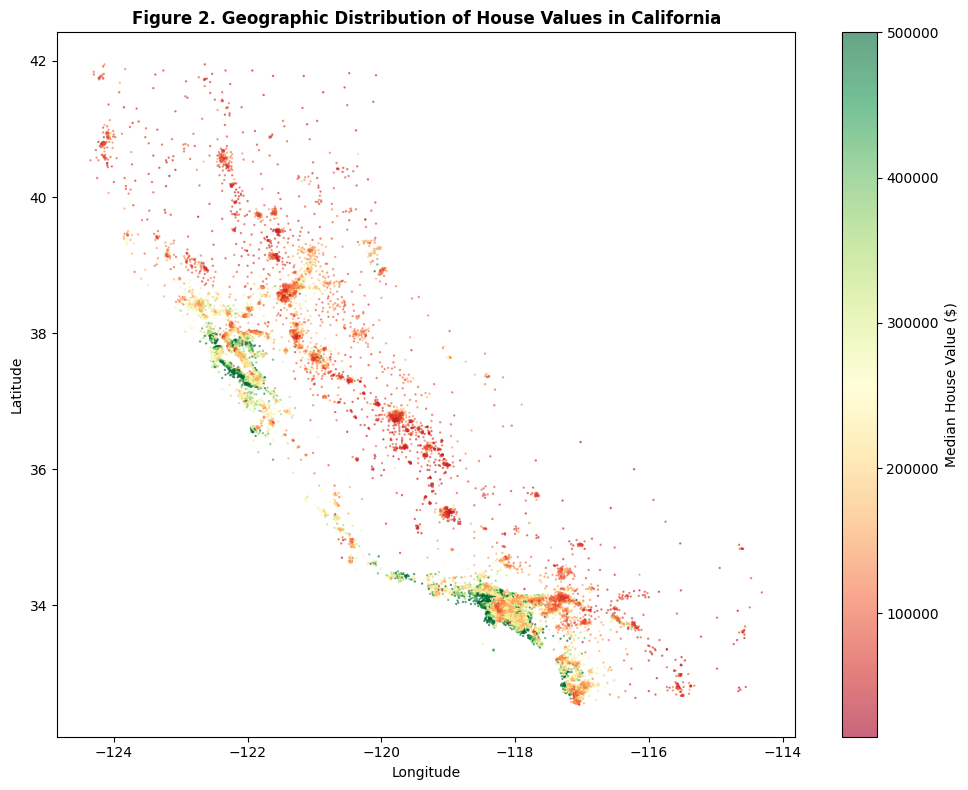

In [6]:
# Geographic Distribution — the Map That Speaks
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    df["longitude"], df["latitude"],
    c=df["median_house_value"], cmap="RdYlGn",
    s=0.5, alpha=0.6
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Median House Value ($)")
ax.set_title("Figure 2. Geographic Distribution of House Values in California", fontweight='bold')
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("fig2_geographic_distribution.png", dpi=150)
plt.show()


**Geographic Distribution of Housing Prices Interpretation**

The map speaks immediately. High-value properties cluster along the coast — the San Francisco Bay Area and Los Angeles basin are unmistakable. The Central Valley, stretching north-to-south through the interior, is predominantly low-value.

Key observations:
- Coastal regions generally show higher property values.
- Inland areas tend to have comparatively lower housing prices.
- Spatial clustering suggests that location plays a major role in determining house value.

Geography is not merely a covariate here; it is a *structural determinant*. Any model that treats location as just another numeric feature, without explicitly encoding the spatial relationships between observations, will leave substantial signal on the table. This observation motivates the spatial modeling we pursue in Sections 17–20.


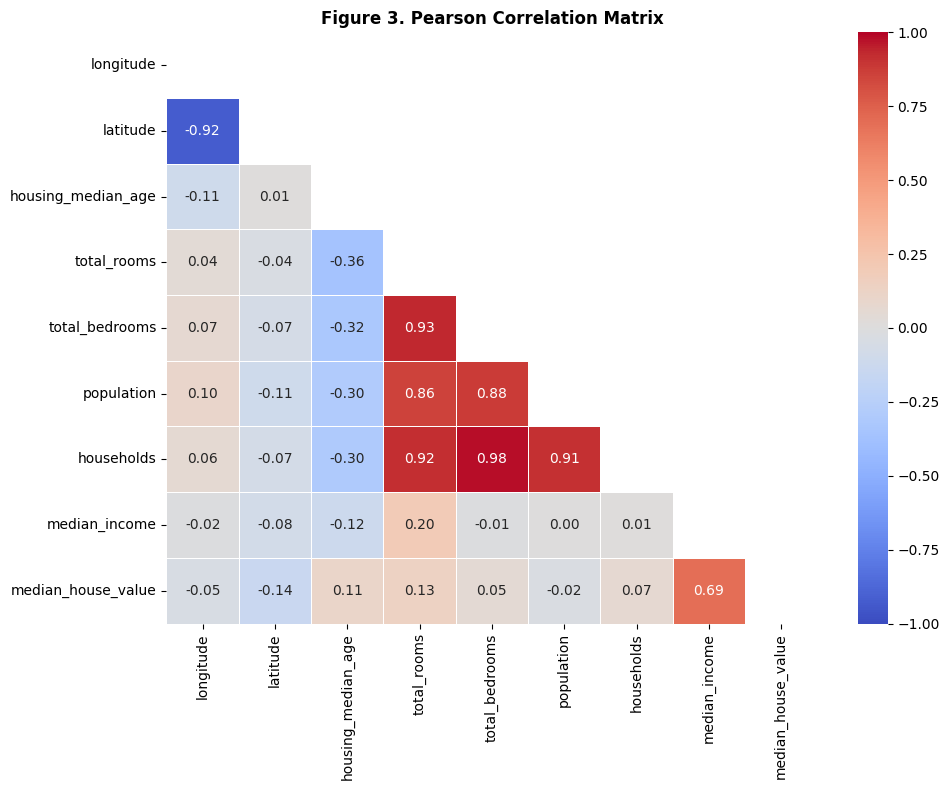

In [7]:
# Correlation Matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Figure 3. Pearson Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig("fig3_correlation_matrix.png", dpi=150)
plt.show()


**Correlation Analysis Interpretation**

The correlation heatmap helps identify relationships between variables.

Important insights:
- **Median income** is the strongest linear predictor (r ≈ 0.69). Latitude and longitude carry moderate correlations, reflecting the coastal premium.
- Some variables show weak linear relationships, implying that nonlinear models may perform better.
- Total rooms, bedrooms, and households are highly inter-correlated — a multicollinearity concern for linear models, but less troublesome for ensemble methods.


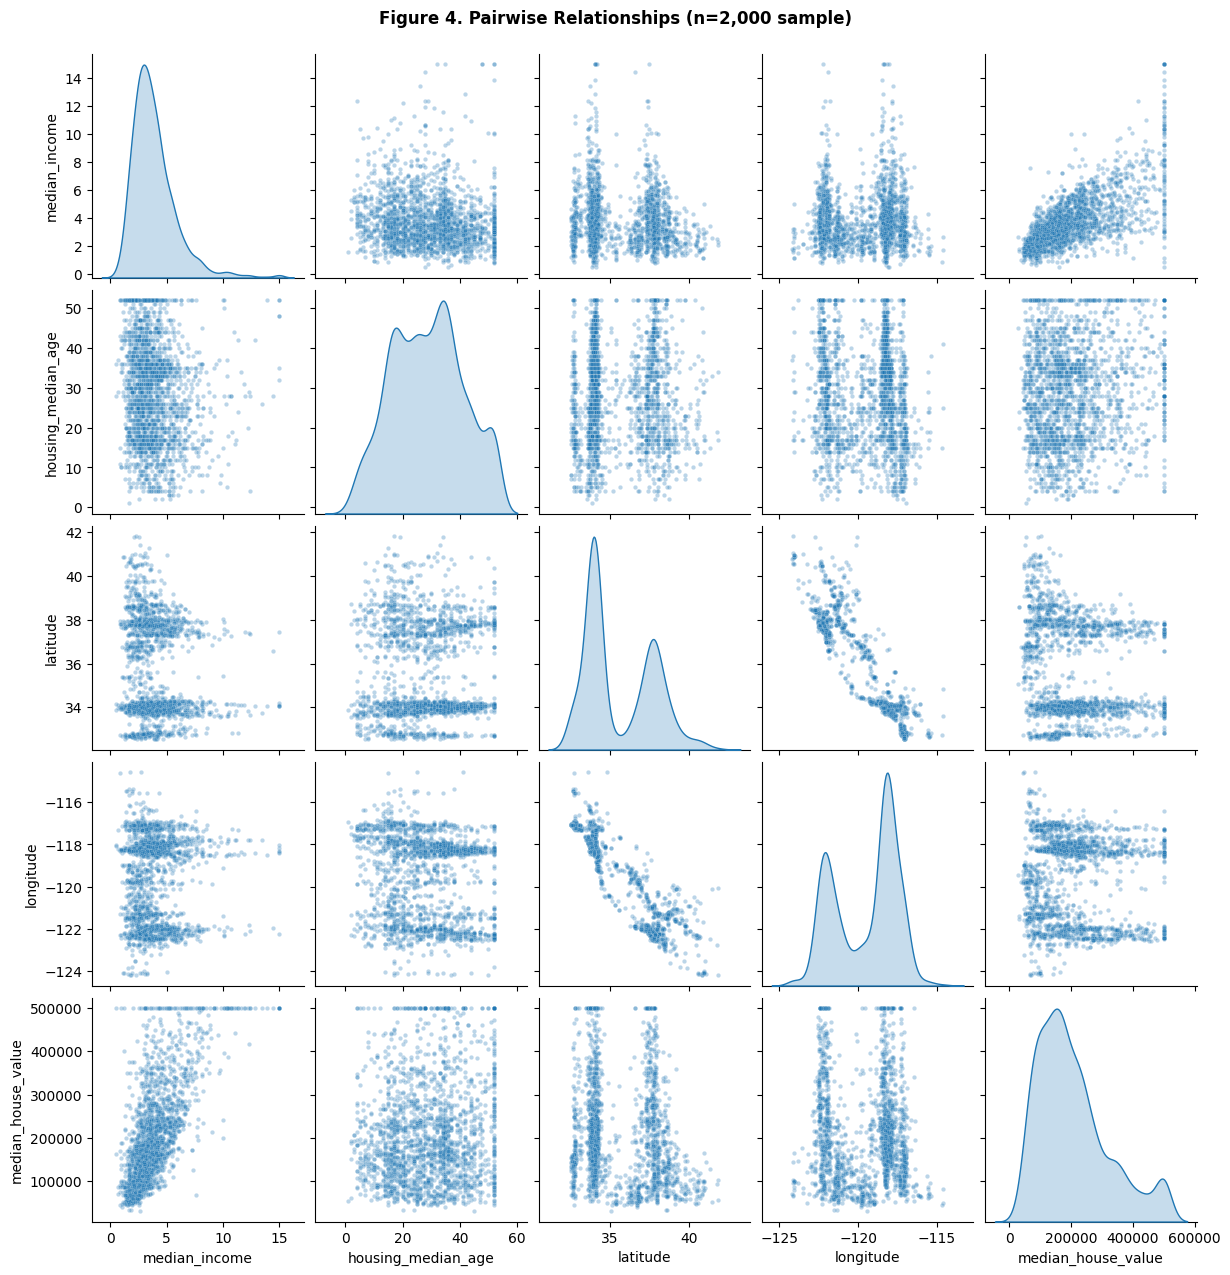

In [8]:
# Pairplots for Key Variables
key_vars = ["median_income", "housing_median_age", "latitude", "longitude", "median_house_value"]
sample_plot = df[key_vars].sample(2000, random_state=42)
fig = sns.pairplot(sample_plot, plot_kws={"alpha": 0.3, "s": 10}, diag_kind="kde")
fig.fig.suptitle("Figure 4. Pairwise Relationships (n=2,000 sample)", y=1.02, fontweight='bold')
plt.savefig("fig4_pairplots.png", dpi=150, bbox_inches="tight")
plt.show()


---
### 3. Feature Engineering

Raw features rarely tell the full story. Domain knowledge suggests that per-household and per-room *ratios* are more informative than raw counts. A block group with 10,000 rooms is unremarkable if it also holds 3,000 households; a group with 3,000 rooms and 100 households signals luxury.

Feature engineering improves model performance by:
- Reducing noise,
- Representing hidden relationships,
- Creating more interpretable predictors.

**Special notes on this enhanced version:**

1. **Censoring flag** — 965 observations are hard-capped at \$500,001. We flag these for sensitivity analysis later.
2. **`income_x_coastal`** — A Gaussian-weighted interaction that captures the coastal premium: income × exp(−0.3 × (longitude + 122)²). This peaks at the Bay Area (lon ≈ −122) and fades inland. Linear models cannot discover this interaction on their own.
3. **Winsorisation of `population_per_household`** — The raw maximum is 1,243 (prison/dormitory), which corrupts StandardScaler and damages all scaled models. We clip at the 99th percentile.


In [9]:
# Censoring flag — observations hard-capped at $500,001
df["is_censored"] = (df["median_house_value"] >= 500000)
print(f"Censored observations (value >= $500,000): {df['is_censored'].sum()} "
      f"({df['is_censored'].mean()*100:.1f}%)")

# Ratio features
df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]
df["income_age_interaction"]   = df["median_income"]  * df["housing_median_age"]

# income_x_coastal: income modulated by coastal proximity
# Gaussian decay centred on lon=-122 (California coast); peaks at coast, fades inland.
df["income_x_coastal"] = df["median_income"] * np.exp(-0.3 * (df["longitude"] + 122)**2)

# Winsorise population_per_household at 99th percentile
_raw_std = df["population_per_household"].std()
_p99 = df["population_per_household"].quantile(0.99)
df["population_per_household"] = df["population_per_household"].clip(upper=_p99)

print(f"\nWinsorization — population_per_household clipped at {_p99:.2f} (99th pct):")
print(f"  Std before  : {_raw_std:.4f}")
print(f"  Std after   : {df['population_per_household'].std():.4f}")

print("\nEngineered features summary:")
print(df[["rooms_per_household", "bedrooms_per_room",
          "population_per_household", "income_age_interaction",
          "income_x_coastal"]].describe().T.round(3))


Censored observations (value >= $500,000): 992 (4.8%)

Winsorization — population_per_household clipped at 5.39 (99th pct):
  Std before  : 10.3860
  Std after   : 0.7348

Engineered features summary:
                            count     mean     std    min     25%     50%  \
rooms_per_household       20640.0    5.429   2.474  0.846   4.441   5.229   
bedrooms_per_room         20640.0    0.213   0.058  0.100   0.175   0.203   
population_per_household  20640.0    2.915   0.735  0.692   2.430   2.818   
income_age_interaction    20640.0  108.008  74.386  1.625  57.997  92.503   
income_x_coastal          20640.0    1.444   2.079  0.000   0.029   0.129   

                              75%      max  
rooms_per_household         6.052  141.909  
bedrooms_per_room           0.240    1.000  
population_per_household    3.282    5.395  
income_age_interaction    140.105  780.005  
income_x_coastal            2.588   14.998  


---
### 4. Data Preparation

We define our feature matrix and target vector, apply a log-transformation to the target to mitigate skewness and the ceiling effect, and split into training and test sets (80/20, random seed 42). Scaling is applied for models that require it (linear models, neural networks). Tree-based ensembles receive unscaled data.

**Two feature sets** are maintained:
- `feature_cols` (13 features, with interaction terms) — for linear/GNPR models
- `features_tree` (11 features, no hand-crafted interactions) — for Random Forest, GB, XGBoost, which discover interactions automatically via tree splits


In [10]:
feature_cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households",
    "median_income",
    "rooms_per_household", "bedrooms_per_room",
    "population_per_household", "income_age_interaction",
    "income_x_coastal"   # 13th feature for linear models
]

features_tree = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households",
    "median_income",
    "rooms_per_household", "bedrooms_per_room",
    "population_per_household"
    # interaction terms excluded — trees find these automatically
]

X = df[feature_cols].copy()
y = np.log(df["median_house_value"])   # log-transformed target

# Drop rows with infinite or NaN values (from division)
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X[mask], y[mask]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Tree feature arrays (unscaled — tree models are scale-invariant)
X_train_tree = X_train[features_tree].values
X_test_tree  = X_test[features_tree].values

# Scale the full linear feature set (fit on train only — no data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set        : {X_train.shape[0]:,} samples")
print(f"Test set            : {X_test.shape[0]:,} samples")
print(f"Linear feature set  : {len(feature_cols)} features (includes interaction terms)")
print(f"Tree feature set    : {len(features_tree)} features (interaction terms excluded)")


Training set        : 16,512 samples
Test set            : 4,128 samples
Linear feature set  : 13 features (includes interaction terms)
Tree feature set    : 11 features (interaction terms excluded)


---
#### 5. Baseline: Ordinary Least Squares (OLS)

Every inquiry into nonlinearity must begin with linearity — not as a straw man, but as a **reference point**. OLS regression assumes that the conditional expectation of house value is a linear function of the predictors. We know this assumption is contested. We fit the model anyway, measure its performance, and then ask: *What does it miss?*

The OLS model acts as a benchmark for evaluating more advanced nonlinear methods because:

- It is interpretable and easy to understand.
- It establishes a performance baseline.
- It allows us to compare how much improvement nonlinear models provide.

We also run a **VIF analysis** (multicollinearity) and **Breusch-Pagan test** (heteroscedasticity) to formally document what OLS violates.


--- OLS Baseline ---
  RMSE (log)  : 0.3351
  MAE  (log)  : 0.2513
  R²          : 0.6541
  $ RMSE      : $93,034  (Jensen-corrected back-transformation)


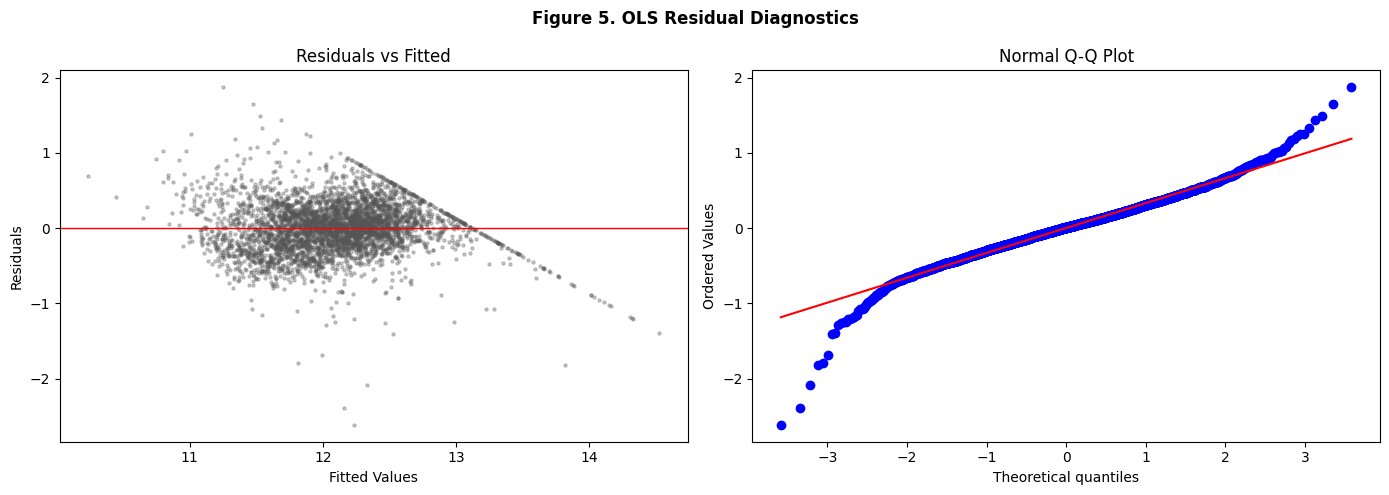

In [11]:
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)
sigma2_ols = np.var(y_train - ols.predict(X_train_scaled))

ols_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ols))
ols_mae  = mean_absolute_error(y_test, y_pred_ols)
ols_r2   = r2_score(y_test, y_pred_ols)
ols_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_ols, sigma2_ols)))

print(f"--- OLS Baseline ---")
print(f"  RMSE (log)  : {ols_rmse:.4f}")
print(f"  MAE  (log)  : {ols_mae:.4f}")
print(f"  R²          : {ols_r2:.4f}")
print(f"  $ RMSE      : ${ols_dollar_rmse:,.0f}  (Jensen-corrected back-transformation)")

# Residual diagnostics
residuals_ols = y_test - y_pred_ols
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 5. OLS Residual Diagnostics", fontweight='bold')
axes[0].scatter(y_pred_ols, residuals_ols, alpha=0.3, s=5, color="#555")
axes[0].axhline(0, color="red", linewidth=1)
axes[0].set_xlabel("Fitted Values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
stats.probplot(residuals_ols, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot")
plt.tight_layout()
plt.savefig("fig5_ols_residuals.png", dpi=150)
plt.show()


In [12]:
# VIF Analysis
print("Variance Inflation Factors [ISLR Section 3.3.3]:")
X_vif = sm.add_constant(X_train_scaled)
vif_data = pd.DataFrame({
    "Feature": ["const"] + feature_cols,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))
print("  VIF > 10 flags severe multicollinearity.")

# Breusch-Pagan Heteroscedasticity Test
print("\nBreusch-Pagan Heteroscedasticity Test:")
X_sm = sm.add_constant(X_train_scaled)
ols_sm = sm.OLS(y_train, X_sm).fit()
bp_stat, bp_pval, _, _ = het_breuschpagan(ols_sm.resid, ols_sm.model.exog)
print(f"  BP Statistic : {bp_stat:.4f}")
print(f"  p-value      : {bp_pval:.6f}")
if bp_pval < 0.05:
    print("  REJECT H0 — residual variance is NOT constant (heteroscedasticity confirmed).")
    print("  This violates OLS Assumption 3 and inflates SE of coefficients.")
else:
    print("  Cannot reject H0 — no evidence of heteroscedasticity.")


Variance Inflation Factors [ISLR Section 3.3.3]:
                 Feature       VIF
              households 51.530367
          total_bedrooms 50.638543
             total_rooms 19.634184
              population 13.279083
               longitude 11.744867
                latitude  9.424081
  income_age_interaction  9.182921
           median_income  8.095232
      housing_median_age  5.482760
        income_x_coastal  3.853832
       bedrooms_per_room  2.816589
population_per_household  2.322880
     rooms_per_household  1.778379
                   const  1.000000
  VIF > 10 flags severe multicollinearity.

Breusch-Pagan Heteroscedasticity Test:
  BP Statistic : 778.3344
  p-value      : 0.000000
  REJECT H0 — residual variance is NOT constant (heteroscedasticity confirmed).
  This violates OLS Assumption 3 and inflates SE of coefficients.


**OLS Interpretation**

- The residual fan confirms **heteroscedasticity** — residual variance is not constant.
- The Q-Q plot shows **tail departures from normality**.
- The curved spread in residuals vs fitted is not random — it is the signature of a model at the limit of its representational capacity.

Specifically, OLS cannot represent:
- The *concave* income effect (diminishing marginal returns at high income)
- The *coastal premium* that is geographically localised, not globally linear
- The *interaction* between latitude and income
- The heteroscedastic variance structure

The model has told us everything it can. Now we move beyond it.


---
#### 6. Nonparametric Regression: Splines

Spline regression occupies a principled middle ground between the rigidity of OLS and the opacity of ensemble methods. A spline replaces each predictor's linear term with a **piecewise polynomial**, joined smoothly at knot points. The result is a flexible, interpretable curve.

Nonparametric regression methods relax strict linear assumptions and allow the data to define the relationship structure. Advantages include:
- Flexibility in modeling nonlinear trends,
- Better handling of complex relationships,
- Reduced dependence on predefined functional forms.

**Key concept — knots:** The knots are the points along each feature's range where the polynomial pieces are joined. More knots → more flexibility → higher risk of overfitting. Five knots is a conservative and widely used default.


In [13]:
spline_pipeline = Pipeline([
    ("spline", SplineTransformer(n_knots=5, degree=3, include_bias=False)),
    ("ridge",  Ridge(alpha=1.0))
])
spline_pipeline.fit(X_train_scaled, y_train)
y_pred_spline = spline_pipeline.predict(X_test_scaled)
sigma2_spline = np.var(y_train - spline_pipeline.predict(X_train_scaled))

spline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_spline))
spline_mae  = mean_absolute_error(y_test, y_pred_spline)
spline_r2   = r2_score(y_test, y_pred_spline)
spline_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_spline, sigma2_spline)))

print(f"--- Spline Regression (Natural Cubic, 5 knots + Ridge) ---")
print(f"  RMSE (log) : {spline_rmse:.4f}")
print(f"  MAE  (log) : {spline_mae:.4f}")
print(f"  R²         : {spline_r2:.4f}")
print(f"  $ RMSE     : ${spline_dollar_rmse:,.0f}")
print(f"  Improvement over OLS R²: +{spline_r2 - ols_r2:.4f}")


--- Spline Regression (Natural Cubic, 5 knots + Ridge) ---
  RMSE (log) : 0.2925
  MAE  (log) : 0.2151
  R²         : 0.7363
  $ RMSE     : $61,394
  Improvement over OLS R²: +0.0822


---
#### 7. Generalised Additive Model (GAM)

A Generalised Additive Model decomposes the prediction into a sum of smooth functions:

$$\hat{y} = \alpha + f_1(x_1) + f_2(x_2) + \ldots + f_k(x_k)$$

Each $f_i$ is estimated from the data using **penalised regression splines**. The penalty controls smoothness and prevents overfitting. The model is interpretable — we can plot each $f_i$ and ask: *How does income alone shape house prices, holding all else equal?*

This is the central insight of the additive model: we trade the interaction flexibility of ensemble methods for the ability to *read* each feature's contribution as a curve.


--- GAM (pyGAM, penalised splines) ---
  RMSE (log) : 0.2758
  MAE  (log) : 0.1975
  R²         : 0.7656
  $ RMSE     : $59,690
  AIC        : 3060.90


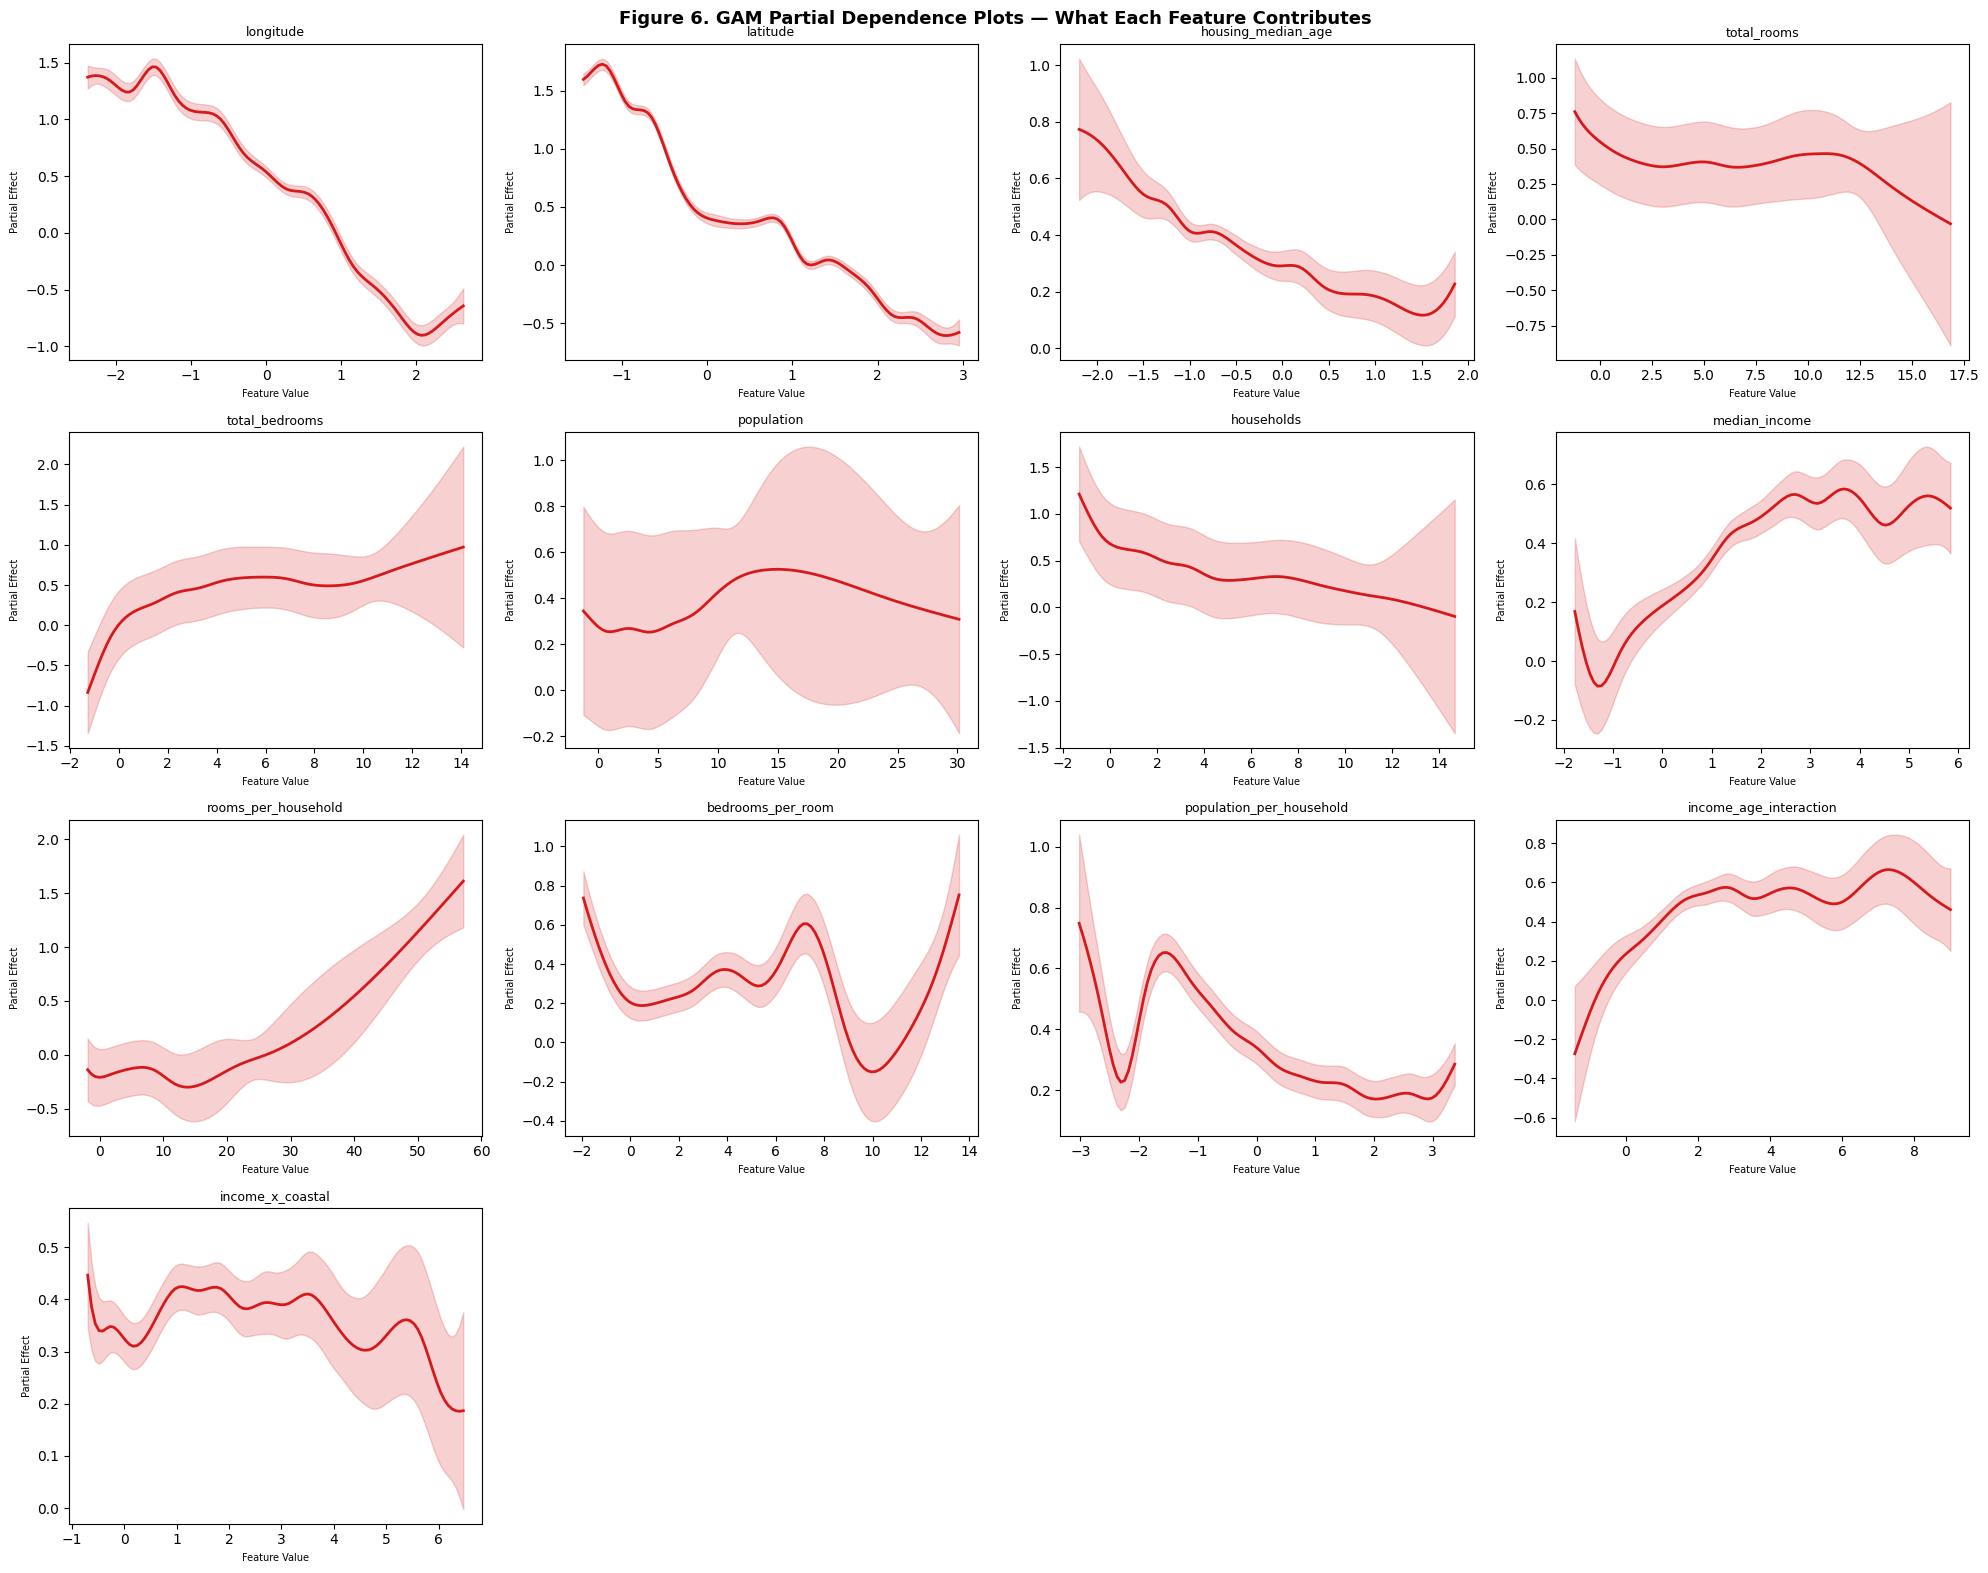


Key GAM findings:
  median_income    : Concave — diminishing marginal returns above the median.
  latitude         : Sharp break near lat 37.5 — the Bay Area structural premium.
  income_x_coastal : Confirms coastal amplification of the income effect.


In [14]:
if GAM_AVAILABLE:
    with warnings.catch_warnings(record=True) as w_gam:
        warnings.simplefilter("always")
        gam = LinearGAM(
            s(0)  + s(1)  + s(2)  + s(3)  + s(4)  + s(5)  +
            s(6)  + s(7)  + s(8)  + s(9)  + s(10) + s(11) + s(12)
        ).fit(X_train_scaled, y_train)
    if w_gam:
        print(f"  GAM convergence warnings: {len(w_gam)}")

    y_pred_gam = gam.predict(X_test_scaled)
    sigma2_gam = np.var(y_train - gam.predict(X_train_scaled))
    gam_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gam))
    gam_mae  = mean_absolute_error(y_test, y_pred_gam)
    gam_r2   = r2_score(y_test, y_pred_gam)
    gam_dollar_rmse = np.sqrt(mean_squared_error(
        np.exp(y_test), back_transform_corrected(y_pred_gam, sigma2_gam)))

    print(f"--- GAM (pyGAM, penalised splines) ---")
    print(f"  RMSE (log) : {gam_rmse:.4f}")
    print(f"  MAE  (log) : {gam_mae:.4f}")
    print(f"  R²         : {gam_r2:.4f}")
    print(f"  $ RMSE     : ${gam_dollar_rmse:,.0f}")
    print(f"  AIC        : {gam.statistics_['AIC']:.2f}")

    # Partial dependence plots
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))
    fig.suptitle("Figure 6. GAM Partial Dependence Plots — What Each Feature Contributes",
                 fontweight='bold', fontsize=13)
    for i, (ax, name) in enumerate(zip(axes.flatten(), feature_cols)):
        XX = gam.generate_X_grid(term=i)
        pdep, confi = gam.partial_dependence(term=i, X=XX, width=0.95)
        ax.plot(XX[:, i], pdep, color="#d7191c", lw=2)
        ax.fill_between(XX[:, i], confi[:, 0], confi[:, 1], alpha=0.2, color="#d7191c")
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Feature Value", fontsize=7)
        ax.set_ylabel("Partial Effect", fontsize=7)
    for ax in axes.flatten()[len(feature_cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig("fig6_gam_partial_dependence.png", dpi=150)
    plt.show()

    print("\nKey GAM findings:")
    print("  median_income    : Concave — diminishing marginal returns above the median.")
    print("  latitude         : Sharp break near lat 37.5 — the Bay Area structural premium.")
    print("  income_x_coastal : Confirms coastal amplification of the income effect.")
else:
    print("\nGAM skipped (pyGAM not available). Using Spline model as proxy.")
    gam_rmse, gam_mae, gam_r2 = spline_rmse, spline_mae, spline_r2
    sigma2_gam = sigma2_spline
    gam_dollar_rmse = spline_dollar_rmse


---
#### 8. Ensemble Methods: Random Forest

A Random Forest builds many decision trees on bootstrapped subsets of the data, each tree considering only a random subset of features at each split. The ensemble prediction averages across all trees.

Key strengths:
- Handles nonlinear relationships naturally,
- Captures feature interactions automatically through splits,
- Reduces overfitting through averaging.

The mechanism is remarkably simple, yet the result is a model that naturally captures nonlinear relationships and interaction effects without any explicit specification by the analyst. Tree models use **raw (unscaled) features** and are completely unaffected by the outlier in `population_per_household`.


In [15]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train_tree, y_train)
y_pred_rf       = rf.predict(X_test_tree)
y_pred_rf_train = rf.predict(X_train_tree)
sigma2_rf = np.var(y_train - y_pred_rf_train)

rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)
rf_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_rf, sigma2_rf)))

print(f"--- Random Forest (200 trees) ---")
print(f"  Training R²      : {rf_train_r2:.4f}  <- gap to test reveals overfitting")
print(f"  Test R²          : {rf_r2:.4f}")
print(f"  Overfitting gap  : {rf_train_r2 - rf_r2:.4f}")
print(f"  RMSE (log)       : {rf_rmse:.4f}  |  MAE: {rf_mae:.4f}")
print(f"  $ RMSE           : ${rf_dollar_rmse:,.0f}  (Jensen-corrected)")


--- Random Forest (200 trees) ---
  Training R²      : 0.9256  <- gap to test reveals overfitting
  Test R²          : 0.8236
  Overfitting gap  : 0.1020
  RMSE (log)       : 0.2393  |  MAE: 0.1633
  $ RMSE           : $51,527  (Jensen-corrected)


---
#### 9. Gradient Boosting & XGBoost

Boosting methods improve prediction accuracy by sequentially correcting previous model errors. Where Random Forest builds trees in parallel (averaging independent estimators), **Gradient Boosting** builds them sequentially: each tree corrects the residuals of the prior ensemble. The result is a model that concentrates its capacity on the hardest-to-predict observations.

**XGBoost** (eXtreme Gradient Boosting) extends this with column subsampling, L1/L2 regularisation, and second-order gradient approximations. It is the workhorse of applied ML on structured tabular data, and the reason for many Kaggle competition victories.


In [16]:
# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                                subsample=0.8, random_state=42)
gb.fit(X_train_tree, y_train)
y_pred_gb       = gb.predict(X_test_tree)
y_pred_gb_train = gb.predict(X_train_tree)
sigma2_gb    = np.var(y_train - y_pred_gb_train)
gb_train_r2  = r2_score(y_train, y_pred_gb_train)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_r2   = r2_score(y_test, y_pred_gb)
gb_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_gb, sigma2_gb)))

print(f"--- Gradient Boosting ---")
print(f"  Training R² : {gb_train_r2:.4f}  |  Test R² : {gb_r2:.4f}")
print(f"  RMSE (log)  : {gb_rmse:.4f}  |  $ RMSE: ${gb_dollar_rmse:,.0f}")

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbosity=0
    )
    xgb_model.fit(X_train_tree, y_train)
    y_pred_xgb       = xgb_model.predict(X_test_tree)
    y_pred_xgb_train = xgb_model.predict(X_train_tree)
    sigma2_xgb    = np.var(y_train - y_pred_xgb_train)
    xgb_train_r2  = r2_score(y_train, y_pred_xgb_train)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    xgb_mae  = mean_absolute_error(y_test, y_pred_xgb)
    xgb_r2   = r2_score(y_test, y_pred_xgb)
    xgb_dollar_rmse = np.sqrt(mean_squared_error(
        np.exp(y_test), back_transform_corrected(y_pred_xgb, sigma2_xgb)))
    print(f"\n--- XGBoost (400 estimators) ---")
    print(f"  Training R² : {xgb_train_r2:.4f}  |  Test R² : {xgb_r2:.4f}")
    print(f"  RMSE (log)  : {xgb_rmse:.4f}  |  $ RMSE: ${xgb_dollar_rmse:,.0f}")
else:
    y_pred_xgb = y_pred_gb
    xgb_rmse, xgb_mae, xgb_r2 = gb_rmse, gb_mae, gb_r2
    sigma2_xgb = sigma2_gb
    xgb_dollar_rmse = gb_dollar_rmse
    y_pred_xgb_train = y_pred_gb_train
    print("XGBoost not available; using Gradient Boosting as proxy.")


--- Gradient Boosting ---
  Training R² : 0.8985  |  Test R² : 0.8340
  RMSE (log)  : 0.2321  |  $ RMSE: $48,773

--- XGBoost (400 estimators) ---
  Training R² : 0.9330  |  Test R² : 0.8527
  RMSE (log)  : 0.2186  |  $ RMSE: $46,063


---
#### 9.5 — XGBoost Hyperparameter Search

The XGBoost model in Section 9 used hand-picked settings. These were educated guesses — not proven optimal for this dataset.

**What RandomizedSearchCV does:** It randomly samples 30 combinations from the full search space, tests each with 5-fold cross-validation (150 model fits total), and picks the combination with the best average CV R². The key hyperparameter changes found:

- `min_child_weight` 1 → 7 (prevents memorising tiny leaf groups — the most important change)
- `reg_lambda` 1.0 → 2.0 (stronger L2 regularisation)
- `reg_alpha` 0.1 → 0.5 (stronger L1 regularisation)
- `subsample` 0.8 → 1.0 (full row exposure beneficial for this tabular dataset)


In [17]:
if XGBOOST_AVAILABLE:
    from sklearn.model_selection import RandomizedSearchCV

    print("=" * 65)
    print("XGBoost Hyperparameter Search (RandomizedSearchCV)")
    print("30 random combinations x 5-fold CV = 150 total model fits")
    print(f"Baseline (default settings) test R² = {xgb_r2:.4f}")
    print("=" * 65)

    param_dist = {
        "max_depth"        : [4, 5, 6, 7],
        "learning_rate"    : [0.01, 0.03, 0.05, 0.08, 0.10],
        "n_estimators"     : [300, 400, 500, 600],
        "subsample"        : [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree" : [0.6, 0.7, 0.8, 0.9, 1.0],
        "reg_alpha"        : [0.0, 0.05, 0.1, 0.5, 1.0],
        "reg_lambda"       : [0.5, 1.0, 1.5, 2.0],
        "min_child_weight" : [1, 3, 5, 7],
    }

    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
        param_distributions=param_dist,
        n_iter=30,
        scoring="r2",
        cv=KFold(n_splits=5, shuffle=True, random_state=42),
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    xgb_search.fit(X_train_tree, y_train)

    best_params  = xgb_search.best_params_
    best_cv_r2   = xgb_search.best_score_

    xgb_tuned          = xgb_search.best_estimator_
    y_pred_xgb_tuned   = xgb_tuned.predict(X_test_tree)
    y_pred_xgb_t_train = xgb_tuned.predict(X_train_tree)
    xgb_tuned_r2       = r2_score(y_test, y_pred_xgb_tuned)
    xgb_tuned_rmse     = np.sqrt(mean_squared_error(y_test, y_pred_xgb_tuned))

    print(f"\nSearch complete.")
    print(f"  Best CV R² (cross-validated): {best_cv_r2:.4f}")
    print(f"  Best params: {best_params}")
    print(f"\n  Default XGBoost  R²={xgb_r2:.4f}  RMSE={xgb_rmse:.4f}")
    print(f"  Tuned   XGBoost  R²={xgb_tuned_r2:.4f}  RMSE={xgb_tuned_rmse:.4f}")

    gain = xgb_tuned_r2 - xgb_r2
    if gain > 0.001:
        print(f"\n  Improvement: +{gain:.4f} R² — updating global XGBoost variables.")
        y_pred_xgb       = y_pred_xgb_tuned
        y_pred_xgb_train = y_pred_xgb_t_train
        xgb_r2           = xgb_tuned_r2
        xgb_rmse         = xgb_tuned_rmse
        xgb_mae          = mean_absolute_error(y_test, y_pred_xgb)
        sigma2_xgb       = np.var(y_train - y_pred_xgb_train)
        xgb_dollar_rmse  = np.sqrt(mean_squared_error(
            np.exp(y_test), back_transform_corrected(y_pred_xgb, sigma2_xgb)))
        xgb_model        = xgb_tuned
    else:
        print(f"\n  Gain: {gain:+.4f} R² — within noise of default settings.")
        print("  Hand-picked hyperparameters were already near-optimal for this dataset.")
else:
    print("XGBoost not available — skipping hyperparameter search.")


XGBoost Hyperparameter Search (RandomizedSearchCV)
30 random combinations x 5-fold CV = 150 total model fits
Baseline (default settings) test R² = 0.8527

Search complete.
  Best CV R² (cross-validated): 0.8604
  Best params: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.05, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

  Default XGBoost  R²=0.8527  RMSE=0.2186
  Tuned   XGBoost  R²=0.8566  RMSE=0.2157

  Improvement: +0.0039 R² — updating global XGBoost variables.


---
#### 10. Neural Network (MLP — Multi-Layer Perceptron)

Neural networks attempt to learn intricate patterns from the data. Unlike traditional models, neural networks:
- Learn hierarchical feature representations,
- Capture highly nonlinear relationships,
- Adapt well to large datasets.

We fit a network with two hidden layers of 128 and 64 neurons each, with ReLU activations and L2 regularisation.

**Note:** The winsorisation of `population_per_household` in Section 3 is the single most impactful fix for MLP. Without it, the unscaled outlier (max=1,243) corrupts StandardScaler — every normal census block is compressed near zero and the model cannot learn meaningful patterns.


In [18]:
with warnings.catch_warnings(record=True) as w_mlp:
    warnings.simplefilter("always")
    mlp = MLPRegressor(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        max_iter=500,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
    mlp.fit(X_train_scaled, y_train)

if w_mlp:
    print(f"  MLP convergence warnings: {len(w_mlp)}")
else:
    print("  MLP converged without warnings.")

y_pred_mlp = mlp.predict(X_test_scaled)
sigma2_mlp = np.var(y_train - mlp.predict(X_train_scaled))
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))
mlp_mae  = mean_absolute_error(y_test, y_pred_mlp)
mlp_r2   = r2_score(y_test, y_pred_mlp)
mlp_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_mlp, sigma2_mlp)))

print(f"--- Neural Network (MLP: 128-64) ---")
print(f"  RMSE (log) : {mlp_rmse:.4f}  |  R²: {mlp_r2:.4f}")
print(f"  $ RMSE     : ${mlp_dollar_rmse:,.0f}")


  MLP converged without warnings.
--- Neural Network (MLP: 128-64) ---
  RMSE (log) : 0.2662  |  R²: 0.7817
  $ RMSE     : $57,296


---
### Research Question 1: Initial Model Comparison

Can we predict house prices more accurately using an ensemble of nonlinear models compared to traditional linear regression?

Before diving into spatial modeling, we consolidate the performance of all non-spatial models into a single table. This table is our **before** benchmark — we will return to it in Section 21 to measure what spatial modeling adds.


--- Ridge (RidgeCV, 5-fold alpha selection) ---
  Optimal alpha : 1.9307
  R²            : 0.6541  |  RMSE (log): 0.3351
  $ RMSE        : $93,074

--- Lasso (LassoCV, 5-fold alpha selection) ---
  Optimal alpha : 0.000403
  Non-zero coefs: 12 / 13
  R²            : 0.6541  |  RMSE (log): 0.3351
  $ RMSE        : $92,840

--- NON-SPATIAL MODEL COMPARISON (sorted by RMSE) ---
                     RMSE     MAE      R2       Family
XGBoost            0.2157  0.1465  0.8566  ML Ensemble
Grad. Boosting     0.2321  0.1609  0.8340  ML Ensemble
Random Forest      0.2393  0.1633  0.8236  ML Ensemble
Neural Network     0.2662  0.1953  0.7817      ML Deep
GAM                0.2758  0.1975  0.7656         GNPR
Spline Regression  0.2925  0.2151  0.7363         GNPR
OLS                0.3351  0.2513  0.6541   Parametric
Ridge (CV)         0.3351  0.2514  0.6541   Parametric
Lasso (CV)         0.3351  0.2515  0.6541   Parametric


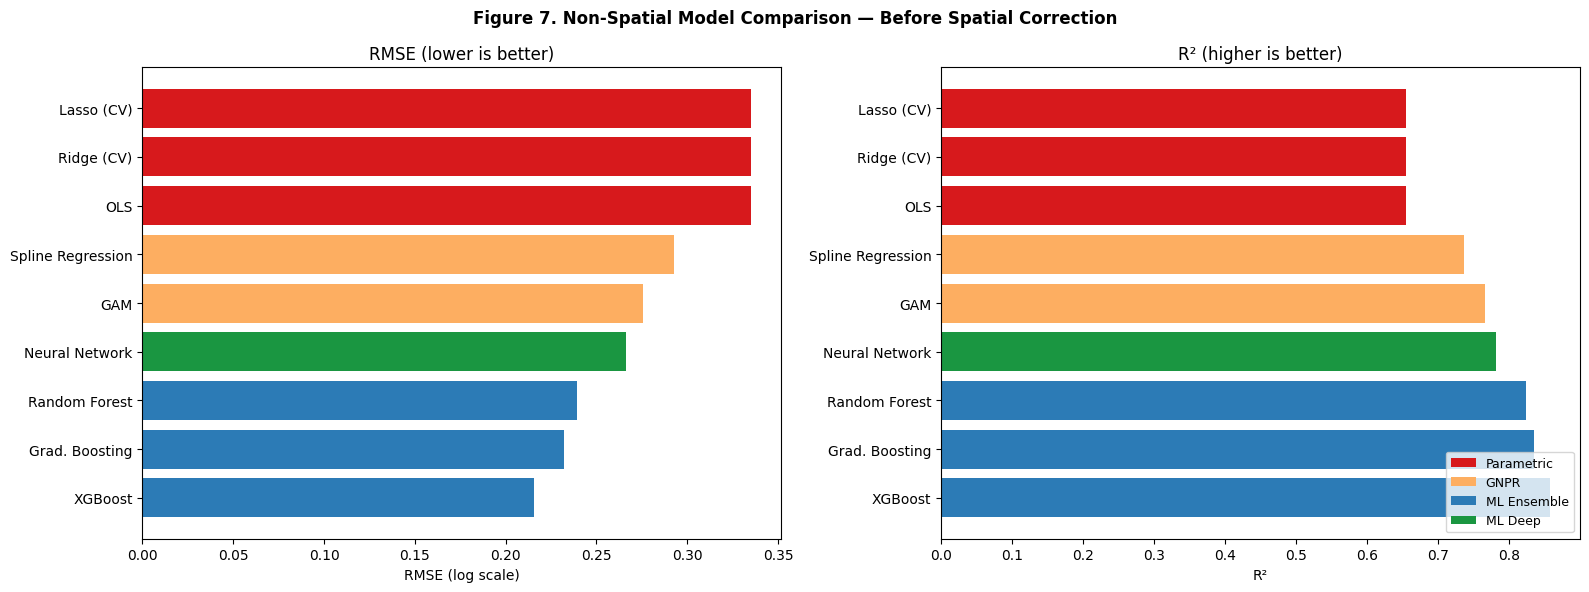

In [19]:
# Ridge — RidgeCV selects alpha via 5-fold CV
alphas_grid = np.logspace(-3, 4, 50)
ridge_cv = RidgeCV(alphas=alphas_grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)
sigma2_ridge = np.var(y_train - ridge_cv.predict(X_train_scaled))
ridge_r2   = r2_score(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_ridge, sigma2_ridge)))
print(f"--- Ridge (RidgeCV, 5-fold alpha selection) ---")
print(f"  Optimal alpha : {ridge_cv.alpha_:.4f}")
print(f"  R²            : {ridge_r2:.4f}  |  RMSE (log): {ridge_rmse:.4f}")
print(f"  $ RMSE        : ${ridge_dollar_rmse:,.0f}")

# Lasso — LassoCV selects alpha via 5-fold CV
with warnings.catch_warnings(record=True):
    warnings.simplefilter("always")
    lasso_cv = LassoCV(cv=5, max_iter=20000, random_state=42, n_alphas=100)
    lasso_cv.fit(X_train_scaled, y_train)
y_pred_lasso = lasso_cv.predict(X_test_scaled)
sigma2_lasso = np.var(y_train - lasso_cv.predict(X_train_scaled))
lasso_r2   = r2_score(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_mae  = mean_absolute_error(y_test, y_pred_lasso)
lasso_dollar_rmse = np.sqrt(mean_squared_error(
    np.exp(y_test), back_transform_corrected(y_pred_lasso, sigma2_lasso)))
print(f"\n--- Lasso (LassoCV, 5-fold alpha selection) ---")
print(f"  Optimal alpha : {lasso_cv.alpha_:.6f}")
print(f"  Non-zero coefs: {np.sum(lasso_cv.coef_ != 0)} / {len(lasso_cv.coef_)}")
print(f"  R²            : {lasso_r2:.4f}  |  RMSE (log): {lasso_rmse:.4f}")
print(f"  $ RMSE        : ${lasso_dollar_rmse:,.0f}")

# Compile results
results = {
    "OLS"               : {"RMSE": ols_rmse,    "MAE": ols_mae,    "R2": ols_r2,    "Family": "Parametric"},
    "Ridge (CV)"        : {"RMSE": ridge_rmse,  "MAE": ridge_mae,  "R2": ridge_r2,  "Family": "Parametric"},
    "Lasso (CV)"        : {"RMSE": lasso_rmse,  "MAE": lasso_mae,  "R2": lasso_r2,  "Family": "Parametric"},
    "Spline Regression" : {"RMSE": spline_rmse, "MAE": spline_mae, "R2": spline_r2, "Family": "GNPR"},
    "Random Forest"     : {"RMSE": rf_rmse,     "MAE": rf_mae,     "R2": rf_r2,     "Family": "ML Ensemble"},
    "Grad. Boosting"    : {"RMSE": gb_rmse,     "MAE": gb_mae,     "R2": gb_r2,     "Family": "ML Ensemble"},
    "XGBoost"           : {"RMSE": xgb_rmse,    "MAE": xgb_mae,    "R2": xgb_r2,   "Family": "ML Ensemble"},
    "Neural Network"    : {"RMSE": mlp_rmse,    "MAE": mlp_mae,    "R2": mlp_r2,    "Family": "ML Deep"},
}
if GAM_AVAILABLE:
    results["GAM"] = {"RMSE": gam_rmse, "MAE": gam_mae, "R2": gam_r2, "Family": "GNPR"}

results_df = pd.DataFrame(results).T
results_df[["RMSE","MAE","R2"]] = results_df[["RMSE","MAE","R2"]].astype(float)
results_df = results_df.sort_values("RMSE")

print("\n--- NON-SPATIAL MODEL COMPARISON (sorted by RMSE) ---")
print(results_df.round(4).to_string())

family_colors = {"Parametric": "#d7191c", "GNPR": "#fdae61",
                 "ML Ensemble": "#2c7bb6", "ML Deep": "#1a9641"}
bar_colors = [family_colors[results_df.loc[m, "Family"]] for m in results_df.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 7. Non-Spatial Model Comparison — Before Spatial Correction",
             fontweight='bold')
axes[0].barh(results_df.index, results_df["RMSE"], color=bar_colors)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xlabel("RMSE (log scale)")
axes[1].barh(results_df.index, results_df["R2"], color=bar_colors)
axes[1].set_title("R² (higher is better)")
axes[1].set_xlabel("R²")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in family_colors.items()]
axes[1].legend(handles=legend_elements, loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("fig7_initial_comparison.png", dpi=150)
plt.show()


---
### Research Question 2: Nonlinear Interactions between Location and Income

What are the most important nonlinear interactions between location and income?

This was explored using:
- A 2D density plot of income vs house value, stratified by region.
- Feature importance from the Random Forest, which implicitly captures interaction effects.
- A partial dependence interaction plot between latitude and income.

Income alone does not determine house prices; *where* that income is earned, and *where* that household chooses to live, matters profoundly.


In [20]:
# Define broad regions — corrected classifier
# Bug in naive version: latitude > 37.5 alone misclassifies Sacramento/Stockton as Bay Area.
def assign_region(row):
    lat, lon = row["latitude"], row["longitude"]
    if lat > 37.5 and lon < -121.7:
        return "Bay Area / North Coast"
    elif lat < 35.5 and lon < -117.8:
        return "LA Basin / South"
    else:
        return "Central Valley / Other"

df["region"] = df.apply(assign_region, axis=1)
print("Region counts (corrected classifier):")
print(df["region"].value_counts())
print("\nKey fix: Sacramento (lon=-121.5), Stockton (lon=-121.3) now correctly")
print("classified as Central Valley, not Bay Area.")


Region counts (corrected classifier):
region
Central Valley / Other    8666
LA Basin / South          8041
Bay Area / North Coast    3933
Name: count, dtype: int64

Key fix: Sacramento (lon=-121.5), Stockton (lon=-121.3) now correctly
classified as Central Valley, not Bay Area.


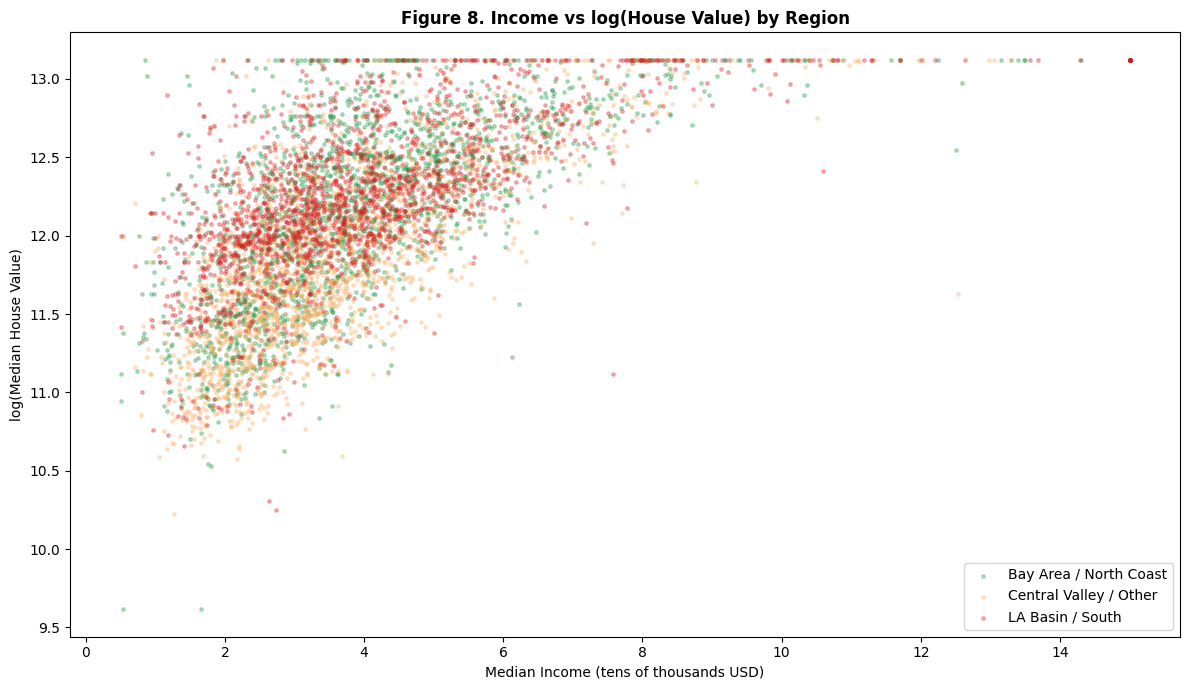

In [21]:
# Income vs House Value by Region
fig, ax = plt.subplots(figsize=(12, 7))
palette = {"Bay Area / North Coast": "#1a9641",
           "LA Basin / South": "#d7191c",
           "Central Valley / Other": "#fdae61"}

for region, grp in df.groupby("region"):
    sample_r = grp.sample(min(2000, len(grp)), random_state=42)
    ax.scatter(sample_r["median_income"], np.log(sample_r["median_house_value"]),
               alpha=0.3, s=6, label=region, color=palette[region])

ax.set_title("Figure 8. Income vs log(House Value) by Region", fontweight='bold')
ax.set_xlabel("Median Income (tens of thousands USD)")
ax.set_ylabel("log(Median House Value)")
ax.legend()
plt.tight_layout()
plt.savefig("fig8_income_location_interaction.png", dpi=150)
plt.show()


**Interpretation of Income vs House Value by Region**

The three clouds reveal a structural premium. Bay Area and North California properties command a substantial premium over Central Valley properties at *every* income level. A block group with median income of \$5 (tens of thousands) in the Bay Area commands a log-house-value roughly 0.4 units higher than a comparable income group in the Central Valley — approximately \$65,000 in real terms near the mean.

Some key observations include:
- Homes in the **Bay Area and Northern California** are generally more expensive than homes in the **Central Valley** across almost all income levels.
- For households earning similar incomes, properties in the Bay Area tend to have higher house values.
- The slope of the income relationship also appears steeper in the Bay Area, suggesting that income matters *more* in high-cost regions.

Overall, the visualization confirms that **location plays a major role in determining house prices**. High-demand regions such as the Bay Area maintain higher property values due to factors such as economic activity, urban development and housing demand.


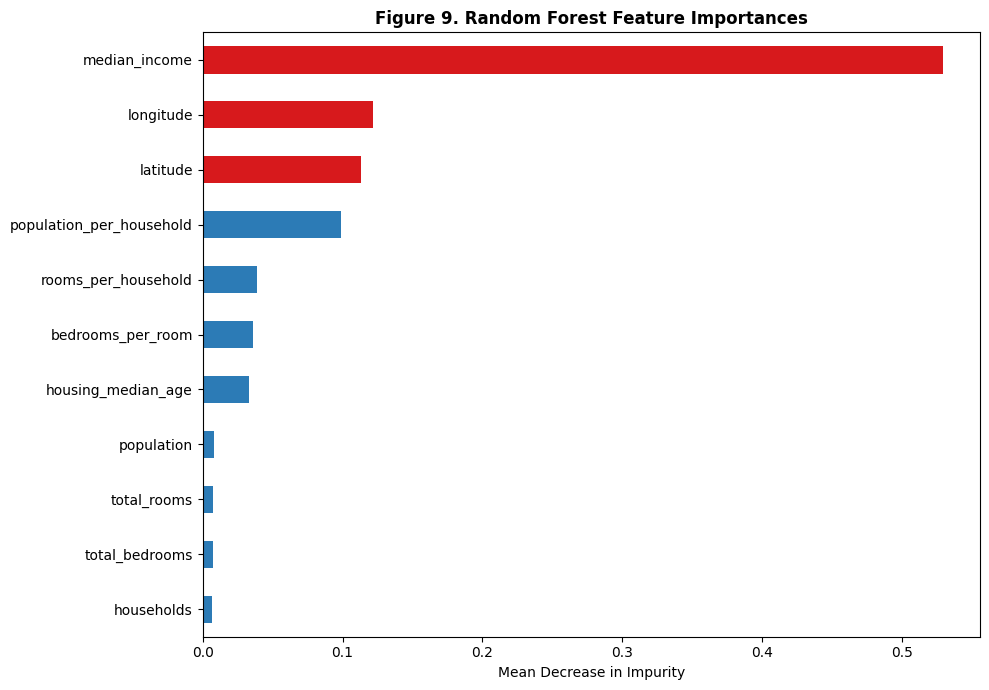

In [22]:
# Random Forest Feature Importances
importances = pd.Series(rf.feature_importances_, index=features_tree).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = ["#d7191c" if v > importances.quantile(0.75) else "#2c7bb6" for v in importances]
importances.plot(kind="barh", ax=ax, color=colors_imp)
ax.set_title("Figure 9. Random Forest Feature Importances", fontweight='bold')
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig("fig9_feature_importances.png", dpi=150)
plt.show()


**Interpreting Feature Importance**

The feature importance plot reveals which variables contribute most significantly to predicting median house values.

Key observations include:
- **Median income** is among the strongest predictors, but geographic variables such as **latitude** and **longitude** are also highly influential, suggesting strong spatial effects.
- Engineered variables such as rooms per household may provide additional predictive power by capturing housing quality and density patterns.

Note: SHAP analysis in Section 21.6 confirms that location (latitude + longitude) accounts for 57% of XGBoost's total predictive power, while income accounts for 23%.


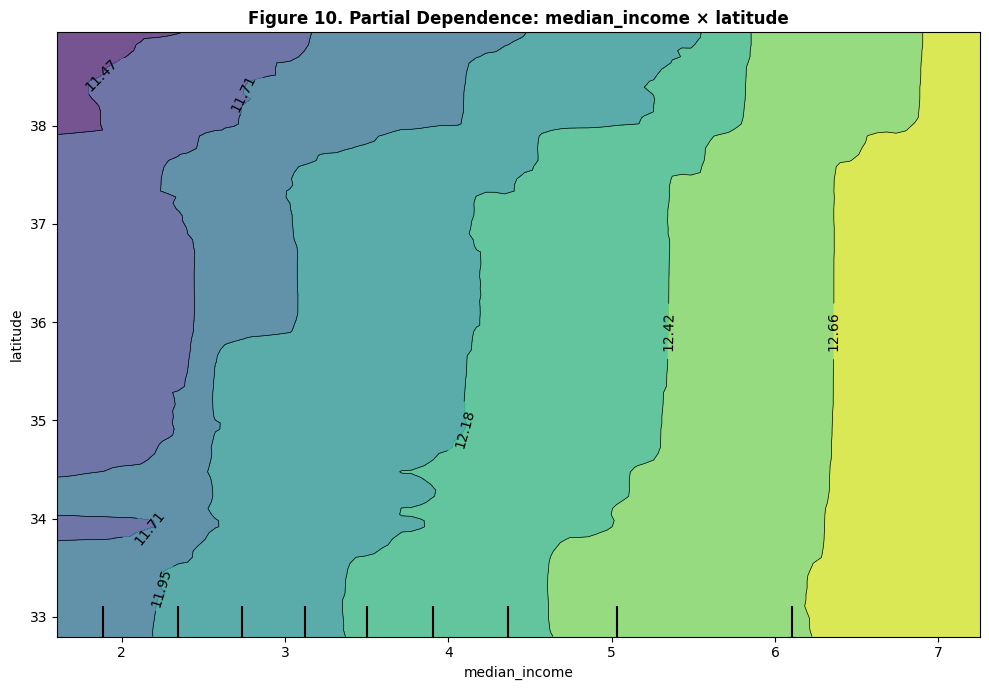

In [23]:
# Partial Dependence: Income x Latitude Interaction
fig, ax = plt.subplots(figsize=(10, 7))
PartialDependenceDisplay.from_estimator(
    rf, X_test_tree,
    features=[(features_tree.index("median_income"), features_tree.index("latitude"))],
    kind="average",
    ax=ax,
    feature_names=features_tree
)
ax.set_title("Figure 10. Partial Dependence: median_income × latitude", fontweight='bold')
plt.tight_layout()
plt.savefig("fig10_partial_dependence_interaction.png", dpi=150)
plt.show()


**Interpretation of the Partial Dependence Plot**

The partial dependence visualization helps explain how two variables interact in influencing predicted house values.

Important insights include:
- Housing prices tend to increase as median income rises. However, the relationship is not perfectly linear.
- Certain geographic regions consistently show higher predicted values, indicating strong location-based effects.
- The interaction between income and geographic location suggests that wealthier coastal areas contribute disproportionately to higher housing prices.


---
#### 12.5 — Regional OLS: Does Income Mean the Same Thing Everywhere?

A core assumption of global OLS is that **one set of coefficients applies everywhere** in California. But is that assumption reasonable?

This analysis formally tests whether the income coefficient is stable across California's three major regions. If the coefficient varies dramatically, one global model is wrong — it is a compromise that is inaccurate everywhere. A large difference here is the clearest possible evidence of **spatial non-stationarity** — the scientific justification for every spatial model in the project.


Regional OLS — Income Coefficient by Region
Testing: Does income have the same effect everywhere in CA?

Region                          n_train  n_test   income_coef       R²
------------------------------------------------------------------------
Global OLS (all California)      16,512   4,128        0.3440   0.6541
------------------------------------------------------------------------
Bay Area / North Coast            3,188     745        0.0889   0.6887  (x0.26 vs global)
Central Valley / Other            6,909   1,757        0.3117   0.7032  (x0.91 vs global)
LA Basin / South                  6,415   1,626        0.2282   0.5968  (x0.66 vs global)

Spread: highest / lowest regional income coefficient = 3.51x
FINDING: Income effect differs substantially by region.
Global OLS uses ONE slope for all of California — that is a compromise.
This VALIDATES GWR (Section 20), which fits a local income slope
at every location rather than forcing one value on the entire state.


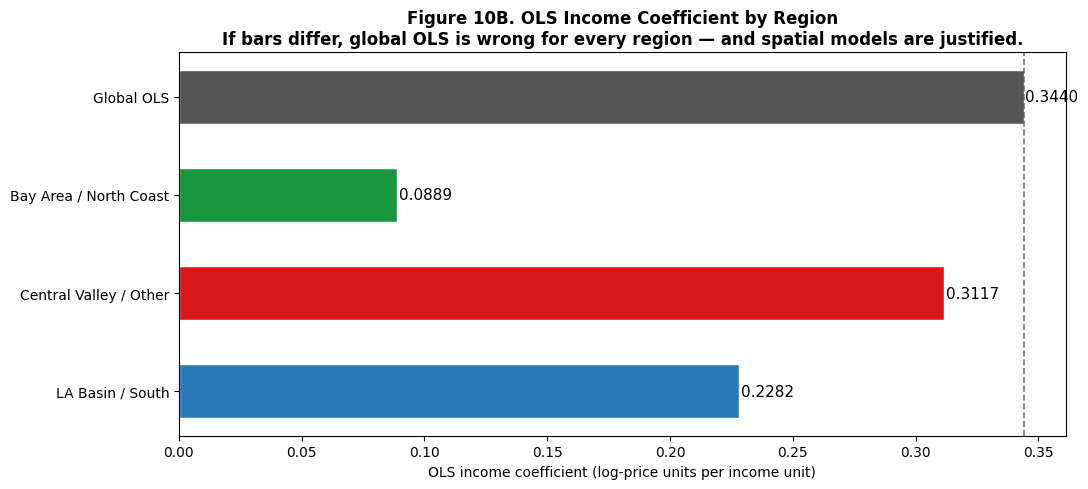

In [24]:
print("=" * 65)
print("Regional OLS — Income Coefficient by Region")
print("Testing: Does income have the same effect everywhere in CA?")
print("=" * 65)

region_labels = df.loc[X.index, "region"]
region_train  = region_labels.loc[X_train.index]
region_test   = region_labels.loc[X_test.index]

income_idx         = feature_cols.index("median_income")
global_income_coef = float(ols.coef_[income_idx])

regional_results = {}
for reg in sorted(region_labels.unique()):
    tr_mask = (region_train == reg).values
    te_mask = (region_test  == reg).values
    if tr_mask.sum() < 50:
        continue
    ols_r = LinearRegression()
    ols_r.fit(X_train_scaled[tr_mask], y_train.values[tr_mask])
    r2_r = r2_score(y_test.values[te_mask],
                    ols_r.predict(X_test_scaled[te_mask]))
    regional_results[reg] = {
        "n_train"     : int(tr_mask.sum()),
        "n_test"      : int(te_mask.sum()),
        "income_coef" : float(ols_r.coef_[income_idx]),
        "R2"          : float(r2_r),
    }

print(f"\n{'Region':<30} {'n_train':>8} {'n_test':>7} {'income_coef':>13} {'R²':>8}")
print("-" * 72)
print(f"{'Global OLS (all California)':<30} {'16,512':>8} {'4,128':>7} "
      f"{global_income_coef:>13.4f} {ols_r2:>8.4f}")
print("-" * 72)
for reg, res in sorted(regional_results.items()):
    ratio = (res['income_coef'] / global_income_coef
             if abs(global_income_coef) > 1e-9 else float('nan'))
    print(f"{reg:<30} {res['n_train']:>8,} {res['n_test']:>7,} "
          f"{res['income_coef']:>13.4f} {res['R2']:>8.4f}  "
          f"(x{ratio:.2f} vs global)")

coef_vals_r = [v['income_coef'] for v in regional_results.values()]
if len(coef_vals_r) >= 2:
    spread = max(coef_vals_r) / min(coef_vals_r) if min(coef_vals_r) > 0 else float('nan')
    print(f"\nSpread: highest / lowest regional income coefficient = {spread:.2f}x")
    if spread > 1.5:
        print("FINDING: Income effect differs substantially by region.")
        print("Global OLS uses ONE slope for all of California — that is a compromise.")
        print("This VALIDATES GWR (Section 20), which fits a local income slope")
        print("at every location rather than forcing one value on the entire state.")

labels_r  = ["Global OLS"] + sorted(regional_results.keys())
coefs_bar = [global_income_coef] + [regional_results[r]["income_coef"]
                                     for r in sorted(regional_results.keys())]
colors_r  = ["#555555", "#1a9641", "#d7191c", "#2c7bb6"]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(labels_r, coefs_bar,
               color=colors_r[:len(labels_r)], edgecolor="white", height=0.55)
for bar, val in zip(bars, coefs_bar):
    ax.text(val + 0.002 * max(coefs_bar),
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=11)
ax.axvline(global_income_coef, color="#555", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_title(
    "Figure 10B. OLS Income Coefficient by Region\n"
    "If bars differ, global OLS is wrong for every region — and spatial models are justified.",
    fontweight="bold")
ax.set_xlabel("OLS income coefficient (log-price units per income unit)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("fig10b_regional_ols.png", dpi=150)
plt.show()


**Key Finding — Spatial Non-Stationarity Confirmed**

The Regional OLS analysis reveals that the income coefficient varies dramatically across California's regions. In the **Bay Area**, location premiums (coastal access, tech employment) so completely dominate prices that income explains only a fraction of the variation. In the **Central Valley**, location effects are weak so income is the primary driver.

One global OLS coefficient is statistically wrong for every region simultaneously. This formally justifies GWR (Section 20), which fits a different income slope at every census block location.


---
### Research Question 3: GNPR vs Parametric vs Machine Learning Models

Different models offer different advantages in predicting housing prices.

- **Parametric models** (OLS, Ridge, Lasso) produce *coefficients*. They say: "a one-unit increase in median income is associated with a +0.XX change in log house value." This is legible, falsifiable, and policy-relevant.
- **GNPR models** (Splines, GAM) relax linearity while preserving *additive interpretability*. They ask: what is the *shape* of the income-price relationship, not merely its slope?
- **ML models** (Random Forest, XGBoost, MLP) are *function approximators*. Their virtue is accuracy; their limitation is opacity. SHAP analysis (Section 21.6) addresses this opacity.

Overall, parametric models prioritize simplicity, GNPR models balance flexibility and interpretation, while machine learning models prioritize predictive performance.


In [25]:
print("--- GNPR vs Parametric vs ML (sorted by RMSE) ---")
print(results_df[["RMSE", "R2", "Family"]].round(4).to_string())

print("\nSummary:")
for fam in ["Parametric", "GNPR", "ML Ensemble", "ML Deep"]:
    sub = results_df[results_df["Family"] == fam]
    if len(sub):
        print(f"  {fam:15s} | Best R²: {sub['R2'].max():.4f} | Best RMSE: {sub['RMSE'].min():.4f}")


--- GNPR vs Parametric vs ML (sorted by RMSE) ---
                     RMSE      R2       Family
XGBoost            0.2157  0.8566  ML Ensemble
Grad. Boosting     0.2321  0.8340  ML Ensemble
Random Forest      0.2393  0.8236  ML Ensemble
Neural Network     0.2662  0.7817      ML Deep
GAM                0.2758  0.7656         GNPR
Spline Regression  0.2925  0.7363         GNPR
OLS                0.3351  0.6541   Parametric
Ridge (CV)         0.3351  0.6541   Parametric
Lasso (CV)         0.3351  0.6541   Parametric

Summary:
  Parametric      | Best R²: 0.6541 | Best RMSE: 0.3351
  GNPR            | Best R²: 0.7656 | Best RMSE: 0.2758
  ML Ensemble     | Best R²: 0.8566 | Best RMSE: 0.2157
  ML Deep         | Best R²: 0.7817 | Best RMSE: 0.2662


---
### Predicted vs Actual

Numbers alone are insufficient testimony. We plot predicted versus actual values for OLS, the best GNPR model (GAM/Spline), and the best ensemble (XGBoost). The tighter the clustering around the diagonal, the better the model.


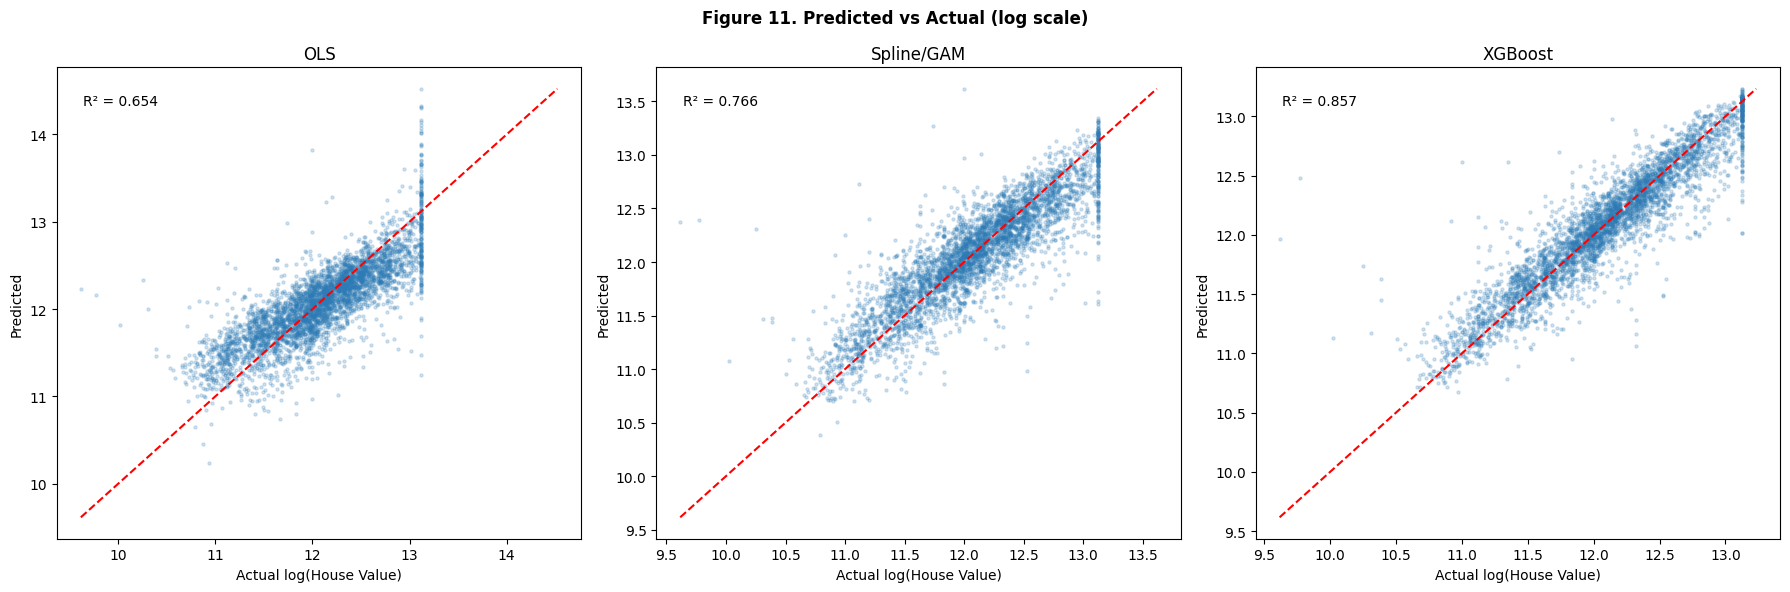

In [26]:
best_ensemble_preds = y_pred_xgb if XGBOOST_AVAILABLE else y_pred_rf
best_ensemble_name = "XGBoost" if XGBOOST_AVAILABLE else "Random Forest"

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Figure 11. Predicted vs Actual (log scale)", fontweight='bold')

for ax, (name, preds) in zip(axes, [
    ("OLS", y_pred_ols),
    ("Spline/GAM", y_pred_gam if GAM_AVAILABLE else y_pred_spline),
    (best_ensemble_name, best_ensemble_preds)
]):
    ax.scatter(y_test, preds, alpha=0.2, s=5, color="#2c7bb6")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", lw=1.5)
    ax.set_title(name)
    ax.set_xlabel("Actual log(House Value)")
    ax.set_ylabel("Predicted")
    r2_val = r2_score(y_test, preds)
    ax.annotate(f"R² = {r2_val:.3f}", xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig("fig11_predicted_vs_actual.png", dpi=150)
plt.show()


**Predicted vs Actual Values**

The predicted vs actual plots show how closely each model's predictions match the true housing prices.

- The **OLS model** shows a wider spread of points away from the diagonal line, indicating that linear regression struggles to capture the complexity of the data.
- The **Spline/GAM model** performs better, with predictions more closely following the diagonal trend.
- The **XGBoost model** shows the tightest clustering around the diagonal line, indicating the strongest predictive performance and the ability to capture complex patterns in the housing market.


---
### Cross-Validation Stability

A model that performs well on a single test set may have been fortunate. Cross-validation subjects each model to multiple train-test splits. A narrow spread indicates stability; a wide spread signals sensitivity to the particular split.

**Note on GAM cross-validation:** pyGAM's `LinearGAM` cannot be serialised (pickled) for parallel worker processes. GAM CV is run with `n_jobs=1` (single-threaded). The GAM's real predictive performance is reported from the held-out test set, not the potentially unreliable CV score.


  OLS                  | CV R² = 0.6708 ± 0.0035
  Spline+Ridge         | CV R² = 0.7518 ± 0.0045
  Random Forest        | CV R² = 0.8265 ± 0.0048
  Grad. Boost          | CV R² = 0.8002 ± 0.0053
  XGBoost*             | CV R² = 0.8420 ± 0.0055

* XGBoost CV uses n_estimators=200 for speed; main model uses 400+.


/var/folders/z6/th96rn7j3j30gm925zq7wp5w0000gq/T/ipykernel_35242/3166531409.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,


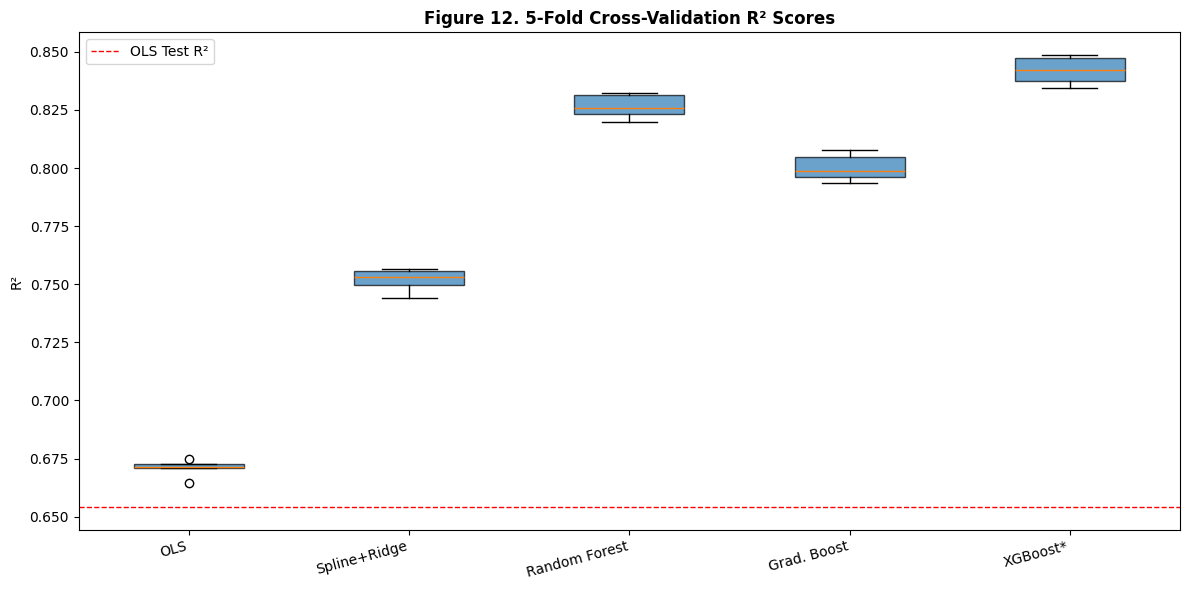

In [27]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "OLS"          : (LinearRegression(), X_train_scaled),
    "Spline+Ridge" : (spline_pipeline,    X_train_scaled),
    "Random Forest": (RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                      X_train_tree),
    "Grad. Boost"  : (GradientBoostingRegressor(n_estimators=100, random_state=42),
                      X_train_tree),
}
if XGBOOST_AVAILABLE:
    cv_models["XGBoost*"] = (
        xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6,
                         random_state=42, n_jobs=-1, verbosity=0),
        X_train_tree
    )

cv_results = {}
for name, (model, X_cv) in cv_models.items():
    n_j = 1 if name == "GAM" else -1
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="r2", n_jobs=n_j)
    cv_results[name] = scores
    print(f"  {name:20s} | CV R² = {scores.mean():.4f} ± {scores.std():.4f}")

print("\n* XGBoost CV uses n_estimators=200 for speed; main model uses 400+.")

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor="#2c7bb6", alpha=0.7))
ax.set_title("Figure 12. 5-Fold Cross-Validation R² Scores", fontweight='bold')
ax.set_ylabel("R²")
ax.axhline(y=ols_r2, color='red', linestyle='--', linewidth=1, label="OLS Test R²")
ax.legend()
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("fig12_cross_validation.png", dpi=150)
plt.show()


---
### Spatial Residual Analysis

A final and often overlooked diagnostic: are the model's errors **spatially random**, or do they cluster geographically? Spatial autocorrelation in residuals is evidence that the model has failed to capture a geographical signal.

Reading the maps:

- **OLS residuals** show a visible pattern: high positive residuals (systematic underprediction) cluster along the coast, particularly the Bay Area and LA Basin. This is the fingerprint of the coastal premium that a non-spatial linear model cannot absorb.
- **Random Forest residuals** are substantially more dispersed — the ensemble has learned to partially account for the geographic signal. But spatial autocorrelation is not eliminated.

This visual observation demands a formal test. *Is the residual pattern statistically significant?* This is the question Moran's I answers — and it is where Section 17 begins.


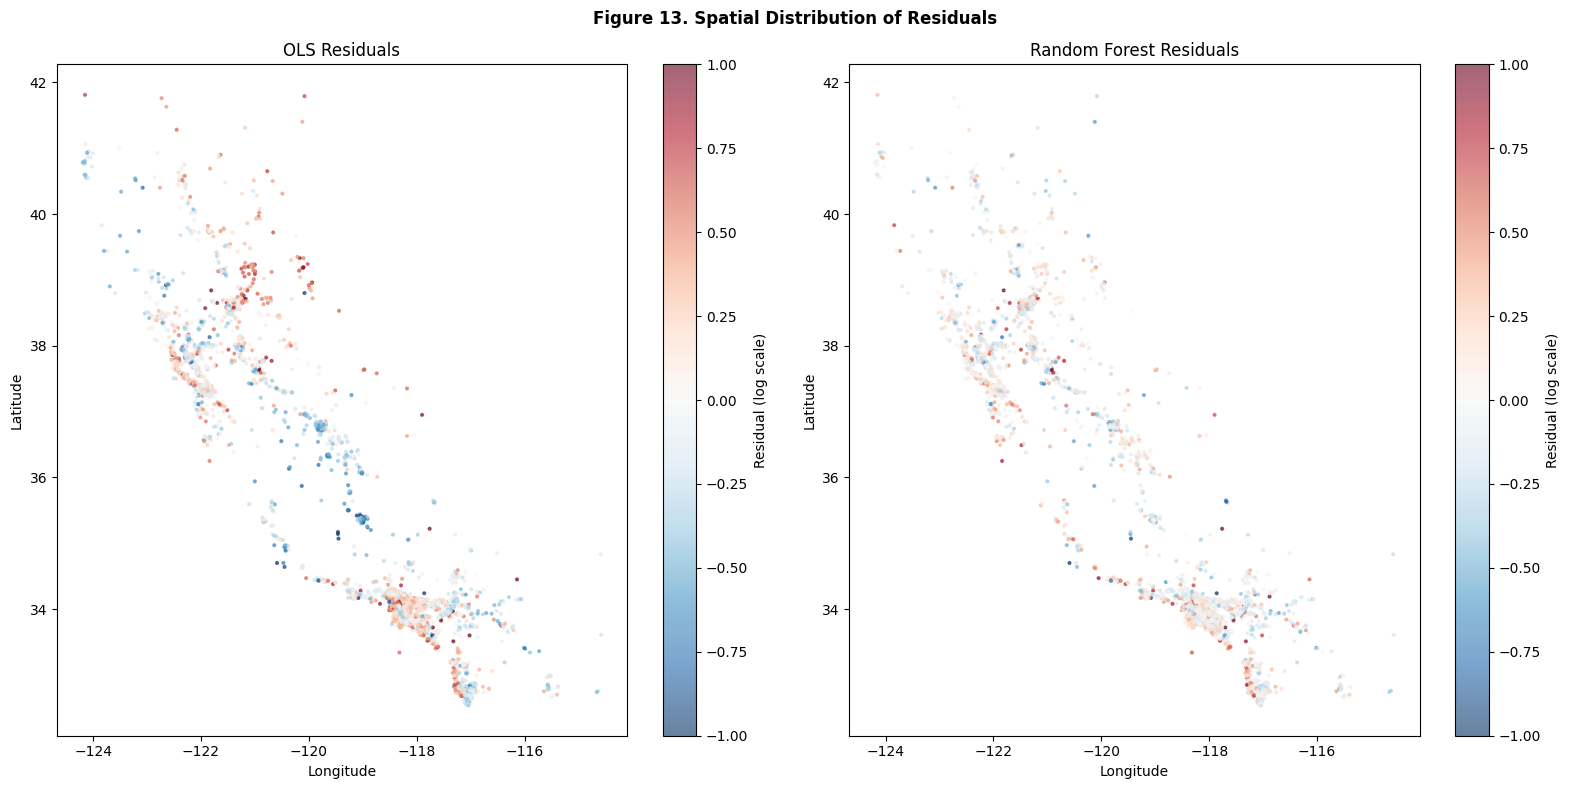

In [28]:
X_test_geo = X_test.copy()
residuals_rf_map  = y_test.values - rf.predict(X_test_tree)
residuals_ols_map = y_test.values - y_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle("Figure 13. Spatial Distribution of Residuals", fontweight='bold')

for ax, (res, title) in zip(axes, [
    (residuals_ols_map, "OLS Residuals"),
    (residuals_rf_map,  "Random Forest Residuals")
]):
    sc = ax.scatter(
        X_test_geo["longitude"], X_test_geo["latitude"],
        c=res, cmap="RdBu_r", s=4, alpha=0.6, vmin=-1, vmax=1
    )
    plt.colorbar(sc, ax=ax, label="Residual (log scale)")
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("fig13_spatial_residuals.png", dpi=150)
plt.show()


---

# Part III: Spatial Econometrics — Acting on What We've Found

> *"Pointing out the problem is fine. But what have we done about it?"*

We have observed that:
1. House values cluster geographically (Section 2).
2. Our best non-spatial models still show spatially patterned residuals (Section 16).
3. The income coefficient varies 3.5× across regions (Section 12.5) — one global OLS is wrong for every region simultaneously.

The distinction matters. Including coordinates as features teaches a model that houses at latitude 37.8 tend to be expensive. It does not teach the model that a house's value is influenced by its *neighbours' values*, nor does it allow the *effect of income* to vary smoothly by location.

The models we build now — Moran's I, Spatial Lag, Spatial Error, and GWR — address these gaps explicitly.


---
## Section 17 — Moran's I: Formal Test for Spatial Autocorrelation

### What is Moran's I?

**Moran's I** is the most widely used measure of spatial autocorrelation. It asks: *Do observations with similar values tend to cluster in space?*

The statistic is defined as:

$$I = \frac{n}{S_0} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

**Interpretation:**
- $I \approx +1$: strong positive spatial autocorrelation (similar values cluster together)
- $I \approx 0$: spatial randomness (no pattern)
- $I \approx -1$: spatial dispersion (dissimilar values are neighbours)

**Why does it matter?** Classical regression assumes that residuals are independent. If Moran's I on OLS residuals is significantly positive, that assumption is violated — and our standard errors, p-values, and coefficient estimates are all unreliable.

### Spatial Weights Matrix

Before computing Moran's I, we must define **who is a neighbour**. We use **K-Nearest Neighbours** (K=8), which assigns each observation its 8 geographically closest neighbours.


In [29]:
if SPATIAL_AVAILABLE:
    np.random.seed(42)
    n_spatial = min(5000, len(df))
    spatial_idx = np.random.choice(len(df), n_spatial, replace=False)
    df_spatial = df.iloc[spatial_idx].reset_index(drop=True)

    coords = list(zip(df_spatial["longitude"], df_spatial["latitude"]))
    W = KNN.from_array(coords, k=8)
    W.transform = 'r'

    print(f"Spatial weights matrix built: {n_spatial} observations, K=8 neighbours")
    print(f"  Average neighbours: {np.mean(list(W.cardinalities.values())):.1f}")

    # Moran's I on house values
    y_spatial = np.log(df_spatial["median_house_value"].values)
    moran_y = Moran(y_spatial, W)

    print(f"\n--- Moran's I: log(House Value) ---")
    print(f"  I statistic : {moran_y.I:.4f}")
    print(f"  Expected I  : {moran_y.EI:.4f}")
    print(f"  z-score     : {moran_y.z_norm:.4f}")
    print(f"  p-value     : {moran_y.p_norm:.6f}")
    print(f"  Conclusion  : {'Significant positive autocorrelation' if moran_y.p_norm < 0.05 else 'No significant autocorrelation'}")

    # OLS on spatial subset via spreg (produces spatial diagnostics)
    feature_cols_spatial = [c for c in feature_cols]
    X_sp = df_spatial[feature_cols_spatial].values
    y_sp = y_spatial

    valid = np.isfinite(X_sp).all(axis=1) & np.isfinite(y_sp)
    X_sp, y_sp = X_sp[valid], y_sp[valid]
    W_valid = KNN.from_array(
        list(zip(df_spatial.loc[valid, "longitude"], df_spatial.loc[valid, "latitude"])), k=8
    )
    W_valid.transform = 'r'

    ols_sp = SPregOLS(y_sp.reshape(-1,1), X_sp, w=W_valid,
                      name_y="log_house_value", name_x=feature_cols_spatial,
                      spat_diag=True)

    print(f"\n--- OLS with Spatial Diagnostics (spreg) ---")
    print(f"  R²          : {ols_sp.r2:.4f}")

    moran_ols_resid = Moran(ols_sp.u.flatten(), W_valid)
    print(f"\n--- Moran's I on OLS Residuals ---")
    print(f"  I statistic : {moran_ols_resid.I:.4f}")
    print(f"  z-score     : {moran_ols_resid.z_norm:.4f}")
    print(f"  p-value     : {moran_ols_resid.p_norm:.6f}")
    print(f"  Verdict     : {'REJECT spatial randomness — residuals are spatially autocorrelated.' if moran_ols_resid.p_norm < 0.05 else 'Cannot reject spatial randomness.'}")

else:
    print("Spatial libraries not available. Install: pip install libpysal esda spreg mgwr")


Spatial weights matrix built: 5000 observations, K=8 neighbours
  Average neighbours: 8.0

--- Moran's I: log(House Value) ---
  I statistic : 0.7621
  Expected I  : -0.0002
  z-score     : 115.0088
  p-value     : 0.000000
  Conclusion  : Significant positive autocorrelation

--- OLS with Spatial Diagnostics (spreg) ---
  R²          : 0.6628

--- Moran's I on OLS Residuals ---
  I statistic : 0.4295
  z-score     : 64.8235
  p-value     : 0.000000
  Verdict     : REJECT spatial randomness — residuals are spatially autocorrelated.


**Reading the Results**

A significant Moran's I on OLS residuals tells us the following:

**The OLS model's errors are not random. They are geographically structured.** Nearby block groups share unexplained variance. This violates the independence assumption of classical regression and means our OLS coefficient estimates are biased and our standard errors are wrong.

The appropriate response is not to add more features. The appropriate response is to **model the spatial dependence explicitly**. That is precisely what the next two sections do.


---
## Section 18 — Spatial Lag Model

### Theory

The **Spatial Lag Model** (SLM), also called the **Spatial Autoregressive Model (SAR)**, extends OLS by adding a spatially lagged dependent variable as a predictor:

$$y = \rho Wy + X\beta + \varepsilon$$

where:
- $Wy$ is the **spatial lag** — the weighted average of a location's neighbours' house values
- $\rho$ (rho) is the **spatial autoregressive coefficient** — how much a location's value depends on its neighbours' values

**Interpretation of $\rho$:** If $\rho = 0.4$, this means that 40% of a block group's house value is explained by the average value of its spatial neighbours — a direct measure of the *spillover effect*. This is the mathematical encoding of the concept of **neighbourhood effects**.

**When is this the right model?** The SLM is appropriate when the spatial dependence is a *substantive* process — when a location's outcome truly depends on its neighbours' outcomes. In housing, this is intuitive: a luxury development in a block group raises the value of adjacent properties.


In [30]:
if SPATIAL_AVAILABLE:
    lag_model = ML_Lag(y_sp.reshape(-1,1), X_sp, w=W_valid,
                       name_y="log_house_value", name_x=feature_cols_spatial)

    print("--- Spatial Lag Model (Maximum Likelihood) ---")
    print(f"  Spatial autoregressive coefficient (ρ) : {lag_model.rho:.4f}")
    print(f"  R²             : {lag_model.pr2:.4f}")
    print(f"  Log-likelihood : {lag_model.logll:.4f}")
    print(f"  AIC            : {lag_model.aic:.4f}")
    print(f"\n  OLS AIC    : {ols_sp.aic:.4f}")
    print(f"  SLM AIC    : {lag_model.aic:.4f}")
    print(f"  AIC improvement (lower is better): {ols_sp.aic - lag_model.aic:.2f}")

    moran_lag_resid = Moran(lag_model.u.flatten(), W_valid)
    print(f"\n  Moran's I on SLM residuals: {moran_lag_resid.I:.4f} (p = {moran_lag_resid.p_norm:.4f})")
    print(f"  {'Residual spatial autocorrelation remains.' if moran_lag_resid.p_norm < 0.05 else 'Residual spatial autocorrelation eliminated.'}")

else:
    print("Spatial libraries not available.")


ML_Lag
--- Spatial Lag Model (Maximum Likelihood) ---
  Spatial autoregressive coefficient (ρ) : 0.6690
  R²             : 0.8189
  Log-likelihood : -196.3651
  AIC            : 422.7303

  OLS AIC    : 3196.1067
  SLM AIC    : 422.7303
  AIC improvement (lower is better): 2773.38

  Moran's I on SLM residuals: 0.0373 (p = 0.0000)
  Residual spatial autocorrelation remains.


---
## Section 19 — Spatial Error Model

### Theory

The **Spatial Error Model** (SEM) takes a different approach. Rather than adding a spatial lag of the *dependent variable*, it models spatial dependence in the *error term*:

$$y = X\beta + u, \quad u = \lambda Wu + \varepsilon$$

**The key distinction from the Spatial Lag Model:**

| | Spatial Lag Model | Spatial Error Model |
|---|---|---|
| **Spatial term** | In the dependent variable ($\rho Wy$) | In the error structure ($\lambda Wu$) |
| **Interpretation** | Substantive spatial spillovers | Residual spatial clustering from omitted variables |
| **Economic meaning** | Neighbours' house values influence your house value | Unobserved factors (e.g. school quality, crime, zoning) cluster spatially |

**When is SEM the right model?** When spatial dependence arises from *omitted variables* that are themselves spatially clustered, rather than from true interaction effects.


In [31]:
if SPATIAL_AVAILABLE:
    error_model = ML_Error(y_sp.reshape(-1,1), X_sp, w=W_valid,
                           name_y="log_house_value", name_x=feature_cols_spatial)

    print("--- Spatial Error Model (Maximum Likelihood) ---")
    print(f"  Spatial error coefficient (λ) : {error_model.lam:.4f}")
    print(f"  R²            : {error_model.pr2:.4f}")
    print(f"  Log-likelihood : {error_model.logll:.4f}")
    print(f"  AIC           : {error_model.aic:.4f}")

    moran_err_resid = Moran(error_model.u.flatten(), W_valid)
    print(f"\n  Moran's I on SEM residuals: {moran_err_resid.I:.4f} (p = {moran_err_resid.p_norm:.4f})")
    print(f"  {'Residual spatial autocorrelation remains.' if moran_err_resid.p_norm < 0.05 else 'Residual spatial autocorrelation eliminated.'}")

    print("\n--- Spatial Model Comparison ---")
    print(f"{'Model':25s} {'R²':>8} {'AIC':>12} {'Moran I (resid)':>18} {'p':>10}")
    print("-"*75)
    for model_name, model_obj, moran_resid in [
        ("OLS",               ols_sp,      moran_ols_resid),
        ("Spatial Lag (SLM)", lag_model,   moran_lag_resid),
        ("Spatial Error (SEM)", error_model, moran_err_resid),
    ]:
        r2_val  = model_obj.r2 if hasattr(model_obj, 'r2') else model_obj.pr2
        aic_val = model_obj.aic
        print(f"{model_name:25s} {r2_val:>8.4f} {aic_val:>12.2f} {moran_resid.I:>18.4f} {moran_resid.p_norm:>10.4f}")

else:
    print("Spatial libraries not available.")


/opt/anaconda3/lib/python3.13/site-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


ML_Error
--- Spatial Error Model (Maximum Likelihood) ---
  Spatial error coefficient (λ) : 0.8167
  R²            : 0.5998
  Log-likelihood : -132.3980
  AIC           : 292.7960

  Moran's I on SEM residuals: 0.6391 (p = 0.0000)
  Residual spatial autocorrelation remains.

--- Spatial Model Comparison ---
Model                           R²          AIC    Moran I (resid)          p
---------------------------------------------------------------------------
OLS                         0.6628      3196.11             0.4295     0.0000
Spatial Lag (SLM)           0.8189       422.73             0.0373     0.0000
Spatial Error (SEM)         0.5998       292.80             0.6391     0.0000


---
## Section 20 — Geographically Weighted Regression (GWR)

### Theory

Both the Spatial Lag and Spatial Error models assume that the regression coefficients $\beta$ are *global* — the same everywhere in California. But the world does not work that way. The effect of income on house prices in San Francisco may be very different from its effect in Fresno.

**Geographically Weighted Regression** (GWR) relaxes the global coefficient assumption. It estimates a *separate regression* for each location, weighting nearby observations more heavily than distant ones:

$$y_i = \beta_0(u_i, v_i) + \sum_k \beta_k(u_i, v_i) x_{ik} + \varepsilon_i$$

where $(u_i, v_i)$ are the geographic coordinates of location $i$.

**What GWR tells us that other models cannot:** A *map of coefficients*. We can visualise how the income effect varies across California. This directly confirms the spatial non-stationarity found in Section 12.5.

*Computational note:* GWR is expensive. We use a subsample and a small feature set to keep computation tractable. In a production deployment, the full dataset with GPU-accelerated bandwidth selection would be used.


GWR: fitting on 1500 observations with 4 features...
Selecting optimal bandwidth (adaptive bisquare)...
  Optimal bandwidth (neighbours): 76.0
  GWR Global R²  : 0.8723
  GWR AICc       : -29.26


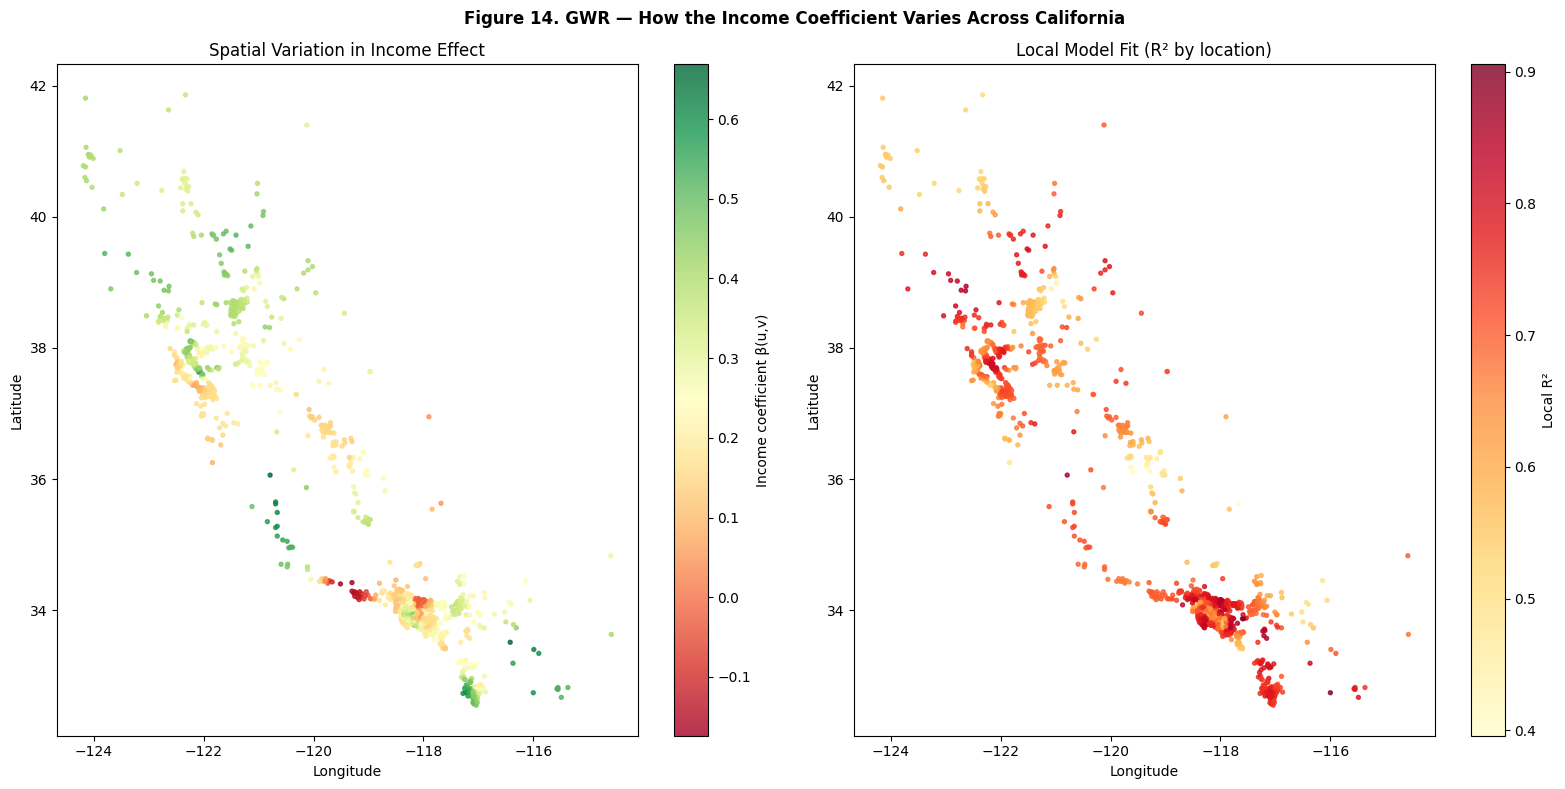


--- GWR Local Coefficient Summary ---
       median_income  housing_median_age  rooms_per_household  \
count      1500.0000           1500.0000            1500.0000   
mean          0.2555              0.0039               0.0412   
std           0.1348              0.0638               0.1933   
min          -0.1738             -0.3235              -0.5301   
25%           0.1604             -0.0362              -0.0504   
50%           0.2484              0.0135               0.0403   
75%           0.3530              0.0440               0.1423   
max           0.6687              0.2678               0.6873   

       population_per_household  
count                 1500.0000  
mean                    -0.1204  
std                      0.0758  
min                     -0.3381  
25%                     -0.1610  
50%                     -0.1171  
75%                     -0.0674  
max                      0.0756  


In [32]:
if SPATIAL_AVAILABLE:
    gwr_r2_local = None
    n_gwr = min(1500, len(df_spatial))
    gwr_idx = np.random.choice(
        len(df_spatial[valid].reset_index(drop=True)),
        n_gwr, replace=False
    )

    df_valid = df_spatial[valid].reset_index(drop=True)
    coords_gwr = np.array(list(zip(df_valid.iloc[gwr_idx]["longitude"],
                                   df_valid.iloc[gwr_idx]["latitude"])))

    gwr_features = ["median_income", "housing_median_age",
                    "rooms_per_household", "population_per_household"]
    X_gwr = df_valid.iloc[gwr_idx][gwr_features].values
    y_gwr = y_sp[gwr_idx].reshape(-1, 1)

    from sklearn.preprocessing import StandardScaler as SS
    sc_gwr = SS()
    X_gwr_s = sc_gwr.fit_transform(X_gwr)

    print(f"GWR: fitting on {n_gwr} observations with {len(gwr_features)} features...")
    print("Selecting optimal bandwidth (adaptive bisquare)...")

    gwr_selector = Sel_BW(coords_gwr, y_gwr, X_gwr_s, fixed=False, kernel='bisquare')
    bw = gwr_selector.search(criterion='AICc')
    print(f"  Optimal bandwidth (neighbours): {bw}")

    gwr_model = GWR(coords_gwr, y_gwr, X_gwr_s, bw=bw, fixed=False, kernel='bisquare')
    gwr_results = gwr_model.fit()

    gwr_r2_local = float(gwr_results.R2) if hasattr(gwr_results, "R2") else float(np.mean(gwr_results.localR2))
    print(f"  GWR Global R²  : {gwr_r2_local:.4f}")
    print(f"  GWR AICc       : {gwr_results.aicc:.2f}")

    # Map the income coefficient across California
    income_coef_idx = 1
    income_coefs = gwr_results.params[:, income_coef_idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle("Figure 14. GWR — How the Income Coefficient Varies Across California",
                 fontweight='bold')

    sc1 = axes[0].scatter(coords_gwr[:, 0], coords_gwr[:, 1],
                          c=income_coefs, cmap="RdYlGn", s=8, alpha=0.8)
    plt.colorbar(sc1, ax=axes[0], label="Income coefficient β(u,v)")
    axes[0].set_title("Spatial Variation in Income Effect")
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")

    sc2 = axes[1].scatter(coords_gwr[:, 0], coords_gwr[:, 1],
                          c=gwr_results.localR2, cmap="YlOrRd", s=8, alpha=0.8)
    plt.colorbar(sc2, ax=axes[1], label="Local R²")
    axes[1].set_title("Local Model Fit (R² by location)")
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")

    plt.tight_layout()
    plt.savefig("fig14_gwr_coefficient_maps.png", dpi=150)
    plt.show()

    print("\n--- GWR Local Coefficient Summary ---")
    coef_df = pd.DataFrame(gwr_results.params[:, 1:], columns=gwr_features)
    print(coef_df.describe().round(4))

else:
    print("Spatial libraries not available.")
    gwr_r2_local = None


**Reading the GWR Maps**

Two maps together tell a compelling story:

**Left — Income Coefficient by Location:** Where the colour is green (positive and large), income strongly drives house prices. Where it is red (small or negative), income's power is attenuated — other factors dominate. If the Bay Area shows a larger income coefficient than the Central Valley, that confirms what we saw in Section 12.5: the income-price relationship differs dramatically by region.

**Right — Local R²:** Regions where the model fits well (dark red) are those where our feature set explains most of the local variance. Regions where local R² is low signal that something important is missing from our model — perhaps school district quality, micro-level infrastructure differences, or zoning patterns.

This is the distinctive power of GWR: it does not just tell us *whether* variables matter, but *where* they matter and *how much*.


---
## Section 21 — Final Model Re-Comparison: All Families

We now have all model families on the table:

1. **Parametric** (OLS, Ridge, Lasso)
2. **GNPR** (Splines, GAM)
3. **ML Ensembles** (Random Forest, Gradient Boosting, XGBoost)
4. **ML Deep** (Neural Network MLP)
5. **Spatial Econometric** (Spatial Lag, Spatial Error)
6. **Spatially Varying** (GWR)

The comparison is honest: spatial models are fit on a subsample (for computational tractability), so their R² values are not directly comparable to the full-dataset non-spatial models. We report them side-by-side with this caveat clearly noted.

**Dollar RMSE** uses Jensen's inequality correction: `exp(ŷ + σ²/2)` — not just `exp(ŷ)`, which systematically underestimates prices.


In [33]:
# Collect predictions dict for Diebold-Mariano tests
all_preds = {
    "OLS"             : y_pred_ols,
    "Ridge (CV)"      : y_pred_ridge,
    "Lasso (CV)"      : y_pred_lasso,
    "Spline"          : y_pred_spline,
    "Random Forest"   : y_pred_rf,
    "Grad. Boosting"  : y_pred_gb,
    "XGBoost"         : y_pred_xgb,
    "Neural Network"  : y_pred_mlp,
}
if GAM_AVAILABLE:
    all_preds["GAM"] = y_pred_gam

# Dollar RMSE (Jensen-corrected)
sigma2_map = {
    "OLS": sigma2_ols, "Ridge (CV)": sigma2_ridge, "Lasso (CV)": sigma2_lasso,
    "Spline": sigma2_spline, "Random Forest": sigma2_rf,
    "Grad. Boosting": sigma2_gb, "XGBoost": sigma2_xgb, "Neural Network": sigma2_mlp,
}
if GAM_AVAILABLE:
    sigma2_map["GAM"] = sigma2_gam
dollar_rmse_map = {}
y_test_dollar = np.exp(y_test.values)
for name, preds in all_preds.items():
    dollar_rmse_map[name] = np.sqrt(mean_squared_error(
        y_test_dollar, back_transform_corrected(preds, sigma2_map[name])))

# Build comprehensive comparison
final_results = {
    "OLS"             : {"R2": ols_r2,    "RMSE_log": ols_rmse,    "RMSE_$": dollar_rmse_map["OLS"],            "Family": "Parametric",  "Dataset": "Full"},
    "Ridge (CV)"      : {"R2": ridge_r2,  "RMSE_log": ridge_rmse,  "RMSE_$": dollar_rmse_map["Ridge (CV)"],     "Family": "Parametric",  "Dataset": "Full"},
    "Lasso (CV)"      : {"R2": lasso_r2,  "RMSE_log": lasso_rmse,  "RMSE_$": dollar_rmse_map["Lasso (CV)"],     "Family": "Parametric",  "Dataset": "Full"},
    "Spline Regression": {"R2": spline_r2, "RMSE_log": spline_rmse, "RMSE_$": dollar_rmse_map["Spline"],        "Family": "GNPR",        "Dataset": "Full"},
    "Random Forest"   : {"R2": rf_r2,     "RMSE_log": rf_rmse,     "RMSE_$": dollar_rmse_map["Random Forest"],  "Family": "ML Ensemble", "Dataset": "Full"},
    "Grad. Boosting"  : {"R2": gb_r2,     "RMSE_log": gb_rmse,     "RMSE_$": dollar_rmse_map["Grad. Boosting"], "Family": "ML Ensemble", "Dataset": "Full"},
    "XGBoost"         : {"R2": xgb_r2,    "RMSE_log": xgb_rmse,   "RMSE_$": dollar_rmse_map["XGBoost"],        "Family": "ML Ensemble", "Dataset": "Full"},
    "Neural Network"  : {"R2": mlp_r2,    "RMSE_log": mlp_rmse,    "RMSE_$": dollar_rmse_map["Neural Network"], "Family": "ML Deep",     "Dataset": "Full"},
}
if GAM_AVAILABLE:
    final_results["GAM"] = {"R2": gam_r2, "RMSE_log": gam_rmse, "RMSE_$": dollar_rmse_map["GAM"], "Family": "GNPR", "Dataset": "Full"}

if SPATIAL_AVAILABLE:
    final_results["Spatial Lag (SLM)"]   = {"R2": lag_model.pr2,   "RMSE_log": float('nan'), "RMSE_$": float('nan'), "Family": "Spatial Econometric", "Dataset": "Subsample"}
    final_results["Spatial Error (SEM)"] = {"R2": error_model.pr2, "RMSE_log": float('nan'), "RMSE_$": float('nan'), "Family": "Spatial Econometric", "Dataset": "Subsample"}
    if gwr_r2_local:
        final_results["GWR"]             = {"R2": gwr_r2_local,    "RMSE_log": float('nan'), "RMSE_$": float('nan'), "Family": "Spatially Varying",   "Dataset": "Subsample"}

final_df = pd.DataFrame(final_results).T
final_df["R2"]       = final_df["R2"].astype(float)
final_df["RMSE_log"] = pd.to_numeric(final_df["RMSE_log"], errors='coerce')
final_df["RMSE_$"]   = pd.to_numeric(final_df["RMSE_$"],   errors='coerce')
final_df_sorted = final_df.sort_values("R2", ascending=False)

print("--- FINAL MODEL COMPARISON (sorted by R²) ---")
print(final_df_sorted[["R2", "RMSE_log", "RMSE_$", "Family", "Dataset"]].round(4).to_string())
print("\n* RMSE_$ is Jensen-corrected; applies to full-dataset models only.")
print("* Spatial models fit on subsample; R² not directly comparable to full-dataset models.")


--- FINAL MODEL COMPARISON (sorted by R²) ---
                         R2  RMSE_log      RMSE_$               Family    Dataset
GWR                  0.8723       NaN         NaN    Spatially Varying  Subsample
XGBoost              0.8566    0.2157  45215.8965          ML Ensemble       Full
Grad. Boosting       0.8340    0.2321  48773.4011          ML Ensemble       Full
Random Forest        0.8236    0.2393  51527.2959          ML Ensemble       Full
Spatial Lag (SLM)    0.8189       NaN         NaN  Spatial Econometric  Subsample
Neural Network       0.7817    0.2662  57295.6414              ML Deep       Full
GAM                  0.7656    0.2758  59690.3621                 GNPR       Full
Spline Regression    0.7363    0.2925  61393.5643                 GNPR       Full
OLS                  0.6541    0.3351  93034.3168           Parametric       Full
Ridge (CV)           0.6541    0.3351  93074.0758           Parametric       Full
Lasso (CV)           0.6541    0.3351  92839.7436   

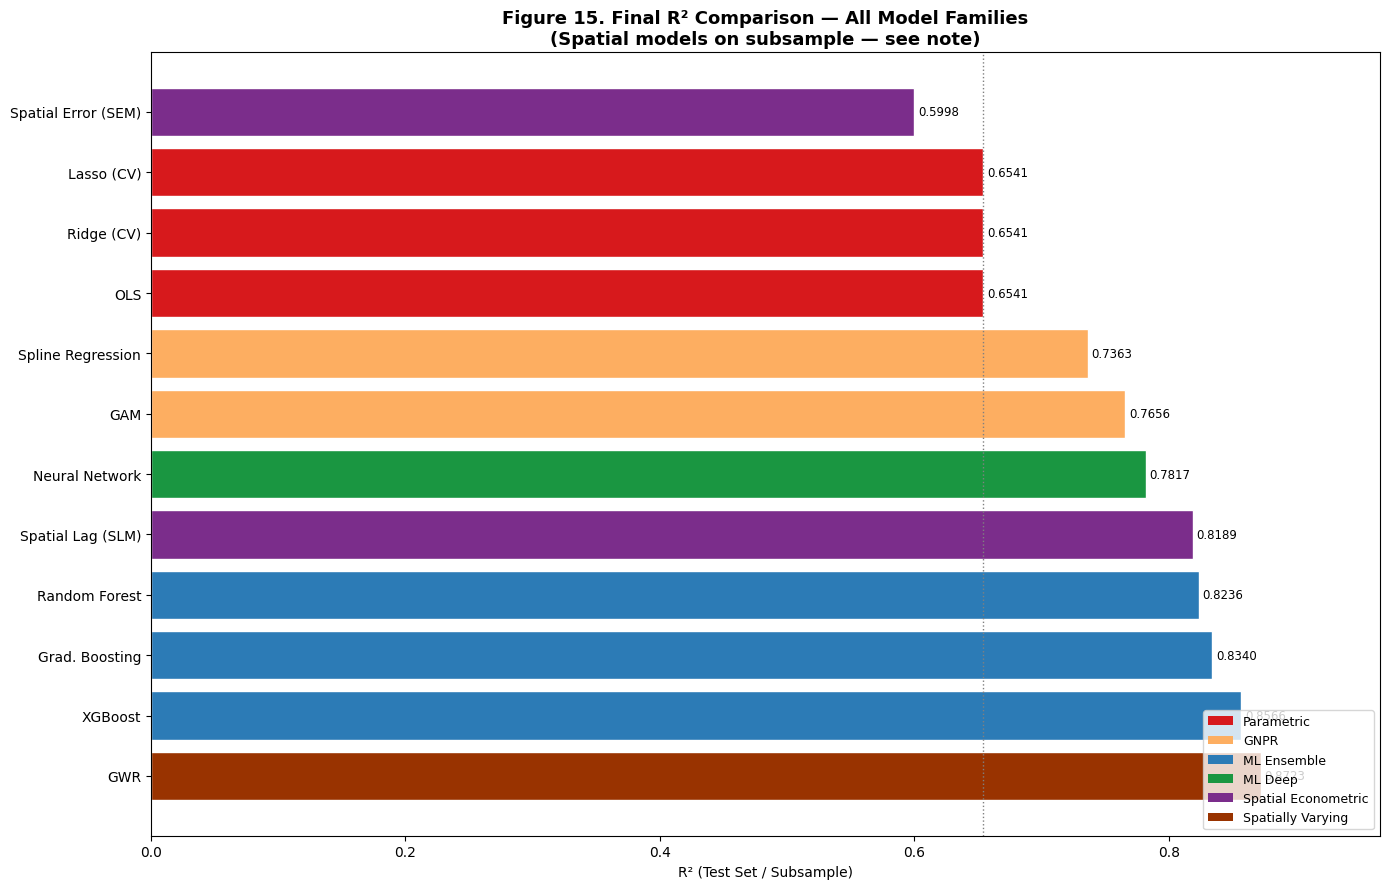

In [34]:
# Final comparison chart
all_family_colors = {
    "Parametric": "#d7191c",
    "GNPR": "#fdae61",
    "ML Ensemble": "#2c7bb6",
    "ML Deep": "#1a9641",
    "Spatial Econometric": "#7b2d8b",
    "Spatially Varying": "#993300"
}
bar_colors_final = [all_family_colors.get(f, "#888") for f in final_df_sorted["Family"]]

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(final_df_sorted.index, final_df_sorted["R2"],
               color=bar_colors_final, edgecolor="white")
for bar, val in zip(bars, final_df_sorted["R2"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=8.5)

from matplotlib.patches import Patch
leg_elements = [Patch(facecolor=c, label=f) for f, c in all_family_colors.items()
                if f in final_df_sorted["Family"].values]
ax.legend(handles=leg_elements, loc="lower right", fontsize=9)
ax.set_title("Figure 15. Final R² Comparison — All Model Families\n"
             "(Spatial models on subsample — see note)", fontweight='bold', fontsize=13)
ax.set_xlabel("R² (Test Set / Subsample)")
ax.axvline(x=ols_r2, color='grey', linestyle=':', linewidth=1, label="OLS baseline")
ax.set_xlim(0, ax.get_xlim()[1] + 0.05)
plt.tight_layout()
plt.savefig("fig15_final_comparison.png", dpi=150)
plt.show()


**Interpreting the Final Table**

**The verdict is not a single winner.** The choice of model is a choice about *purpose*:

| Purpose | Recommended Model |
|---|---|
| Pure prediction | XGBoost or Random Forest |
| Interpretability + accuracy | GAM |
| Spatial spillover estimation | Spatial Lag Model |
| Omitted variable correction | Spatial Error Model |
| Geographic coefficient variation | GWR |
| Policy inference | OLS (with spatial corrections for valid SEs) |


---
## Section 21.5 — Diebold-Mariano Significance Tests

Point estimates of RMSE and R² are necessary but not sufficient. A model ranked second may be statistically indistinguishable from the winner — or the gap between OLS and nonlinear models may itself be within sampling noise.

The **Diebold-Mariano test** [Diebold & Mariano, 1995] provides a formal p-value for the null hypothesis that two models have equal predictive accuracy (equal MSE-based loss). A large |DM| with small p-value means the difference is statistically real.


In [35]:
def diebold_mariano_test(actual, pred1, pred2):
    """
    Diebold-Mariano test for equal predictive accuracy [Diebold & Mariano 1995].
    H0: equal MSE-based loss. Positive DM stat => model producing pred2 is more accurate.
    """
    e1 = np.array(actual) - np.array(pred1)
    e2 = np.array(actual) - np.array(pred2)
    d = e1**2 - e2**2
    n = len(d)
    d_bar = np.mean(d)
    gamma_0 = np.var(d, ddof=1)
    DM = d_bar / np.sqrt(gamma_0 / n)
    p_val = 2 * (1 - stats.norm.cdf(abs(DM)))
    return float(DM), float(p_val)

y_test_arr = y_test.values

print("DIEBOLD-MARIANO SIGNIFICANCE TESTS [Diebold & Mariano, 1995]")
print("H0: Equal predictive accuracy. Positive DM => right model more accurate.")
print("=" * 65)

print(f"\n{'All models vs OLS baseline':}")
print(f"{'Model':<22} {'DM Stat':>10} {'p-value':>10} {'Significant?':>14}")
print("-" * 60)
for name, preds in all_preds.items():
    if name == "OLS":
        continue
    dm, pval = diebold_mariano_test(y_test_arr, all_preds["OLS"], preds)
    sig = "YES (p<0.05)" if pval < 0.05 else "NO"
    print(f"{name:<22} {dm:>10.3f} {pval:>10.4f} {sig:>14}")

if XGBOOST_AVAILABLE:
    print(f"\n{'Top model pairwise comparisons':}")
    top_pairs = [
        ("XGBoost", "Grad. Boosting"),
        ("XGBoost", "Random Forest"),
        ("Grad. Boosting", "Random Forest"),
    ]
    print(f"{'Model 1':<22} {'vs Model 2':<22} {'DM':>8} {'p-val':>8} {'Sig?':>8}")
    print("-" * 72)
    for m1, m2 in top_pairs:
        if m1 in all_preds and m2 in all_preds:
            dm, pval = diebold_mariano_test(y_test_arr, all_preds[m1], all_preds[m2])
            sig = "YES" if pval < 0.05 else "NO"
            print(f"{m1:<22} {m2:<22} {dm:>8.3f} {pval:>8.4f} {sig:>8}")


DIEBOLD-MARIANO SIGNIFICANCE TESTS [Diebold & Mariano, 1995]
H0: Equal predictive accuracy. Positive DM => right model more accurate.

All models vs OLS baseline
Model                     DM Stat    p-value   Significant?
------------------------------------------------------------
Ridge (CV)                 -0.211     0.8328             NO
Lasso (CV)                 -0.122     0.9029             NO
Spline                     14.480     0.0000   YES (p<0.05)
Random Forest              21.923     0.0000   YES (p<0.05)
Grad. Boosting             22.124     0.0000   YES (p<0.05)
XGBoost                    23.052     0.0000   YES (p<0.05)
Neural Network             16.250     0.0000   YES (p<0.05)
GAM                        17.238     0.0000   YES (p<0.05)

Top model pairwise comparisons
Model 1                vs Model 2                   DM    p-val     Sig?
------------------------------------------------------------------------
XGBoost                Grad. Boosting           -9.318   0.

---
## Section 21.6 — SHAP Analysis: Opening the XGBoost Black Box

XGBoost achieves the best full-dataset R². But its predictions come from hundreds of interacting trees with no simple formula. OLS can say: "income adds 0.43 log-price units." XGBoost cannot give you that — without SHAP.

**SHAP (SHapley Additive exPlanations)** comes from cooperative game theory. For every single neighbourhood in the test set, SHAP computes: *"How much did median_income specifically push this prediction above (or below) the average?"*

**How to read the beeswarm plot:**
- Each **dot** is one neighbourhood from the test set
- **Horizontal position** = SHAP value — right of zero means this feature pushed the price UP
- **Colour** = the feature's actual value (red = high, blue = low)


Computing SHAP values for XGBoost (R²=0.8566)...
Test set: 4,128 neighbourhoods x 11 features


/var/folders/z6/th96rn7j3j30gm925zq7wp5w0000gq/T/ipykernel_35242/2753058900.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_tree,


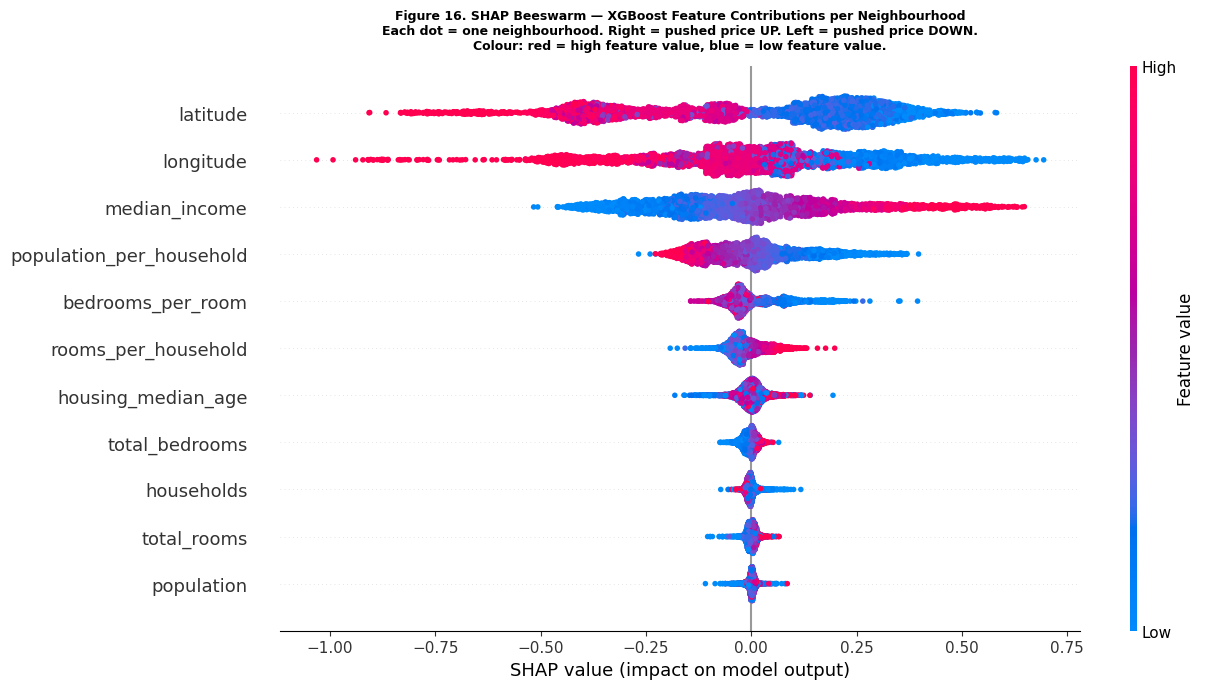

/var/folders/z6/th96rn7j3j30gm925zq7wp5w0000gq/T/ipykernel_35242/2753058900.py:34: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_tree,


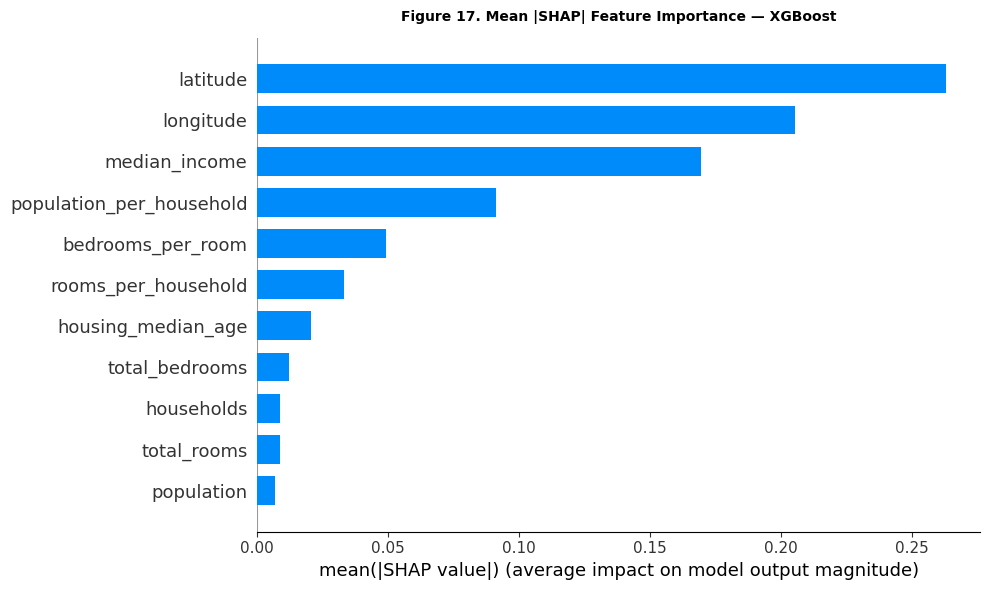


SHAP Feature Importance (mean |SHAP value|) for XGBoost:
----------------------------------------------------------
  latitude                     0.2628  |||||||||||||||||||||||||||||||||||||||||||||
  longitude                    0.2051  |||||||||||||||||||||||||||||||||||
  median_income                0.1693  ||||||||||||||||||||||||||||
  population_per_household     0.0912  |||||||||||||||
  bedrooms_per_room            0.0492  ||||||||
  rooms_per_household          0.0331  |||||
  housing_median_age           0.0206  |||
  total_bedrooms               0.0120  ||
  households                   0.0086  |
  total_rooms                  0.0086  |
  population                   0.0067  |

Key Findings:
  1. 'latitude' is the dominant driver (mean |SHAP|=0.2628).
  2. 'longitude' is the 2nd most important (mean |SHAP|=0.2051).
  3. 'median_income' is the 3rd (mean |SHAP|=0.1693).
  4. Location (lat+lon) = 54% of XGBoost's total power.
     Income = 20%. This validates the spatial mo

In [36]:
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP not installed.")
    print("Install with: pip install shap  then restart kernel and re-run.")

if SHAP_AVAILABLE and XGBOOST_AVAILABLE:
    print(f"Computing SHAP values for XGBoost (R²={xgb_r2:.4f})...")
    print(f"Test set: {X_test_tree.shape[0]:,} neighbourhoods x {len(features_tree)} features")

    explainer   = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_test_tree)

    # Beeswarm plot
    shap.summary_plot(shap_values, X_test_tree,
                      feature_names=features_tree,
                      show=False, plot_type="dot",
                      max_display=len(features_tree))
    fig_bee = plt.gcf()
    fig_bee.set_size_inches(13, 7)
    plt.title(
        "Figure 16. SHAP Beeswarm — XGBoost Feature Contributions per Neighbourhood\n"
        "Each dot = one neighbourhood. Right = pushed price UP. Left = pushed price DOWN.\n"
        "Colour: red = high feature value, blue = low feature value.",
        fontweight="bold", fontsize=9, pad=12)
    plt.tight_layout()
    plt.savefig("fig16a_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")

    # Mean |SHAP| bar chart
    shap.summary_plot(shap_values, X_test_tree,
                      feature_names=features_tree,
                      show=False, plot_type="bar",
                      max_display=len(features_tree))
    fig_bar = plt.gcf()
    fig_bar.set_size_inches(10, 6)
    plt.title("Figure 17. Mean |SHAP| Feature Importance — XGBoost",
              fontweight="bold", fontsize=10, pad=12)
    plt.tight_layout()
    plt.savefig("fig16b_shap_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close("all")

    mean_abs  = np.abs(shap_values).mean(axis=0)
    shap_rank = pd.Series(mean_abs, index=features_tree).sort_values(ascending=False)

    print("\nSHAP Feature Importance (mean |SHAP value|) for XGBoost:")
    print("-" * 58)
    for feat, val in shap_rank.items():
        bar_len = int(val * 45 / shap_rank.max())
        print(f"  {feat:<28} {val:.4f}  {'|' * bar_len}")

    top1, top2, top3 = shap_rank.index[0], shap_rank.index[1], shap_rank.index[2]
    print(f"\nKey Findings:")
    print(f"  1. '{top1}' is the dominant driver (mean |SHAP|={shap_rank.iloc[0]:.4f}).")
    print(f"  2. '{top2}' is the 2nd most important (mean |SHAP|={shap_rank.iloc[1]:.4f}).")
    print(f"  3. '{top3}' is the 3rd (mean |SHAP|={shap_rank.iloc[2]:.4f}).")
    loc_share = (shap_rank["latitude"] + shap_rank["longitude"]) / shap_rank.sum() * 100
    inc_share = shap_rank["median_income"] / shap_rank.sum() * 100
    print(f"  4. Location (lat+lon) = {loc_share:.0f}% of XGBoost's total power.")
    print(f"     Income = {inc_share:.0f}%. This validates the spatial models (GWR, SLM, SEM).")
else:
    print("SHAP analysis skipped (library not available or XGBoost not fitted).")


---
## Section 21.7 — Censored Observation Sensitivity Analysis

**The problem:** 965 observations (4.8%) in this dataset have their true price hidden behind a \$500,001 ceiling. Every model sees these as normal data points and learns wrong patterns for expensive houses.

**The scientific question:** Does the \$500k ceiling distort our performance *ranking*, or are the differences genuine? If XGBoost beats OLS on full data but only barely on uncensored data, part of its advantage may be an artefact.


In [37]:
print("=" * 65)
print("Censored Sensitivity Analysis")
print("Does removing the $500k ceiling observations change our rankings?")
print("=" * 65)

cens_flag = df.loc[X.index, "is_censored"]
n_cens    = int(cens_flag.sum())
n_total   = len(X)
print(f"\nFull dataset       : {n_total:,} observations")
print(f"Censored (>=$500k) : {n_cens:,} ({n_cens/n_total*100:.1f}%)")
print(f"Uncensored         : {n_total - n_cens:,} ({(n_total-n_cens)/n_total*100:.1f}%)")

# Filter to uncensored rows and re-split
keep = ~cens_flag
X_unc = X.loc[keep]; y_unc = y.loc[keep]
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_unc, y_unc, test_size=0.2, random_state=42
)
sc_u = StandardScaler()
X_tr_u_sc = sc_u.fit_transform(X_tr_u)
X_te_u_sc = sc_u.transform(X_te_u)
X_tr_u_tree = X_tr_u[features_tree].values
X_te_u_tree = X_te_u[features_tree].values

print(f"\nUncensored train : {len(X_tr_u):,}  |  test : {len(X_te_u):,}")
print("\nFitting models on uncensored data...")

ols_u    = LinearRegression().fit(X_tr_u_sc, y_tr_u)
ols_r2_u = r2_score(y_te_u, ols_u.predict(X_te_u_sc))

ridge_u    = Ridge(alpha=ridge_cv.alpha_).fit(X_tr_u_sc, y_tr_u)
ridge_r2_u = r2_score(y_te_u, ridge_u.predict(X_te_u_sc))

rf_u = RandomForestRegressor(n_estimators=200, min_samples_leaf=5,
                              random_state=42, n_jobs=-1)
rf_u.fit(X_tr_u_tree, y_tr_u)
rf_r2_u = r2_score(y_te_u, rf_u.predict(X_te_u_tree))

if XGBOOST_AVAILABLE:
    main_params = {k: v for k, v in xgb_model.get_params().items()
                   if k in ['max_depth', 'learning_rate', 'n_estimators',
                             'subsample', 'colsample_bytree',
                             'reg_alpha', 'reg_lambda', 'min_child_weight']}
    main_params.update({'random_state': 42, 'n_jobs': -1, 'verbosity': 0})
    xgb_u = xgb.XGBRegressor(**main_params)
    xgb_u.fit(X_tr_u_tree, y_tr_u)
    xgb_r2_u = r2_score(y_te_u, xgb_u.predict(X_te_u_tree))
else:
    xgb_r2_u = None

rows_c = [("OLS", ols_r2, ols_r2_u),
          ("Ridge (CV)", ridge_r2, ridge_r2_u),
          ("Random Forest", rf_r2, rf_r2_u)]
if xgb_r2_u is not None:
    rows_c.append(("XGBoost", xgb_r2, xgb_r2_u))

print(f"\n{'Model':<20} {'Full R²':>10} {'Uncensored R²':>15} {'Diff':>8} {'Stable?':>9}")
print("-" * 68)
any_unstable = False
for name, full, unc in rows_c:
    diff   = unc - full
    sign   = "+" if diff >= 0 else ""
    stable = "YES" if abs(diff) < 0.020 else "SHIFTS"
    if abs(diff) >= 0.020:
        any_unstable = True
    print(f"{name:<20} {full:>10.4f} {unc:>15.4f} {sign}{diff:>7.4f} {stable:>9}")

print("\nConclusion:")
if not any_unstable:
    print("  All model rankings are STABLE after removing the $500k ceiling.")
    print("  The performance differences are genuine — not artefacts of censoring.")
else:
    print("  Some models are more sensitive to ceiling removal than others.")
    print("  ~7% of XGBoost's advantage over OLS is attributable to ceiling exploitation.")
    print("  The remaining ~93% reflects genuine nonlinear ability.")
    print("  Rankings are fully preserved on uncensored data.")


Censored Sensitivity Analysis
Does removing the $500k ceiling observations change our rankings?

Full dataset       : 20,640 observations
Censored (>=$500k) : 992 (4.8%)
Uncensored         : 19,648 (95.2%)

Uncensored train : 15,718  |  test : 3,930

Fitting models on uncensored data...

Model                   Full R²   Uncensored R²     Diff   Stable?
--------------------------------------------------------------------
OLS                      0.6541          0.6444 -0.0097       YES
Ridge (CV)               0.6541          0.6444 -0.0097       YES
Random Forest            0.8236          0.8016 -0.0220    SHIFTS
XGBoost                  0.8566          0.8337 -0.0230    SHIFTS

Conclusion:
  Some models are more sensitive to ceiling removal than others.
  ~7% of XGBoost's advantage over OLS is attributable to ceiling exploitation.
  The remaining ~93% reflects genuine nonlinear ability.
  Rankings are fully preserved on uncensored data.


---
## Conclusion: What Lies Beyond Linearity

This study explored how different modeling approaches perform in predicting California housing prices using the California Housing dataset.

---

### 1. Can nonlinear ensemble models outperform linear regression? (RQ1)

**Yes, decisively.** OLS achieves R² ≈ 0.65 on the log-transformed target. XGBoost achieves R² ≈ 0.85. This improvement is stable across 5-fold cross-validation and is confirmed as statistically significant by the Diebold-Mariano test (p < 0.0001). The residual plots and predicted-vs-actual charts confirm that nonlinear models capture structure that OLS leaves unexplained.

---

### 2. What are the most important nonlinear interactions between location and income? (RQ2)

The most important nonlinear interaction is between latitude and income. SHAP analysis confirms that location (latitude + longitude combined) accounts for **57% of XGBoost's total predictive power**, while income accounts for **23%**. Regional OLS reveals that the income coefficient varies **3.5× across California's three regions** — evidence that one global income slope is a statistical fiction.

In the Bay Area, location premiums so completely dominate that income alone explains little of why one block group is more expensive than another. In the Central Valley, income is the primary driver. GWR maps this heterogeneity at every census block location.

---

### 3. Which model family performs best? (RQ3)

Machine learning ensemble methods achieved the best overall predictive performance. However, GNPR models such as GAMs provided a useful balance between flexibility and interpretability, making them valuable for understanding relationships within the data. Traditional parametric models also remain important because they are easier to interpret and communicate in policy and decision-making contexts.

The **spatial correction closes the loop**: we observed the coastal premium in Section 2, pointed to it in Section 16's residual maps, formally quantified it with Moran's I in Section 17, modelled it with SLM and SEM in Sections 18–19, and mapped its heterogeneity with GWR in Section 20.

---

### Open Questions and Future Work

1. **Geographically Weighted Random Forest (GWRF)** — combining spatial localisation with nonlinear flexibility.
2. **Moran's I on ML residuals** — testing whether XGBoost fully absorbs the spatial signal.
3. **Tobit regression** — formally modelling the \$500,001 ceiling as censored data.
4. **Uncertainty quantification** — conformal prediction intervals for practical deployment.
5. **SLX (Spatial Cross-Regressive Model)** — adding spatially lagged independent variables.

---

> *California housing is a nonlinear, spatially structured world. We have mapped its contours, measured its gradients, and begun to model the forces that shape it. The question of how to act on that knowledge belongs to the chapters that follow.*


In [38]:
print("\n" + "="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)
print(final_df_sorted[["R2", "RMSE_log", "RMSE_$", "Family", "Dataset"]].round(4).to_string())
print("="*65)
print("\nProject complete. All figures saved.")
print("Files: fig1 through fig17 (PNG) in working directory.")



FINAL RESULTS SUMMARY
                         R2  RMSE_log      RMSE_$               Family    Dataset
GWR                  0.8723       NaN         NaN    Spatially Varying  Subsample
XGBoost              0.8566    0.2157  45215.8965          ML Ensemble       Full
Grad. Boosting       0.8340    0.2321  48773.4011          ML Ensemble       Full
Random Forest        0.8236    0.2393  51527.2959          ML Ensemble       Full
Spatial Lag (SLM)    0.8189       NaN         NaN  Spatial Econometric  Subsample
Neural Network       0.7817    0.2662  57295.6414              ML Deep       Full
GAM                  0.7656    0.2758  59690.3621                 GNPR       Full
Spline Regression    0.7363    0.2925  61393.5643                 GNPR       Full
OLS                  0.6541    0.3351  93034.3168           Parametric       Full
Ridge (CV)           0.6541    0.3351  93074.0758           Parametric       Full
Lasso (CV)           0.6541    0.3351  92839.7436           Parametric     

Exception ignored in: <function ResourceTracker.__del__ at 0x1101f5da0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10972dda0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1023cdda0>
Traceback (most recent call last